# <p style="text-align: center; color: red;"> Modelling and Control of Cement Emissions using ML</p> 

# <p style="text-align: left; color: yellow;"> Sheikh Junaid Fayaz -- M3RG Lab -- Indian Institute of Technology, Delhi</p> 
# <p style="text-align: left; color: yellow;"> Date : 06 March 2026</p> 

In [1]:
import importlib
import functions  # First import
importlib.reload(functions)  # Reloads the module to reflect changes
from functions import *  # Now import updated functions

In [2]:
# #add_custom_fonts(loc=".myfonts")
# import subprocess
# from shadow.plot import *
# from new_plot import * #This line is throwing an error #Solved by commenting out some of the keys of rcParams()

# Read Filtered (quantile & Nestor) data

In [ ]:
df_merged = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/df_merged.pkl')
total_filter = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/total_filter_co.pkl')
total_filter_nox_sp = pd.read_pickle("/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/total_filter_nox_del_25.pkl")
total_filter_co2_sp = pd.read_pickle("/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/total_filter_co2_del_149.pkl")
df_filtered_quantile = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/filtered_quantile.pkl')

##remove nestor's unreliable params
df_filtered_quantile.drop(['Exit temperature from each preheater cyclone (Stage 5)',
'Flue gas outlet temperature (calciner outlet)',
'Flue gas O2 content (calciner outlet)',
'Clinker outlet temperature'], axis = 1, inplace = True)

# TS data for optimization

In [ ]:
main = df_merged[df_merged['no_missing'] > 19][['NOx content in the raw gas (preheater outlet)', 'no_missing']]
main.reset_index(inplace = True)
main.drop(columns=['index'], inplace = True)
offset_20_min = df_merged.drop(columns = ['timestamp','no_missing', 'index_present_original','CO2 content in the raw gas (preheater outlet)','CO content in the raw gas (preheater outlet)', 'NOx content in the raw gas (preheater outlet)']).iloc[:-20,:]
nox_20min_past_PP = pd.concat([main, offset_20_min], axis = 1)
# fi = total_filter_nox_sp['no_missing'].to_list()
fi = df_filtered_quantile['no_missing'].to_list()
nox_20min_past_PP = nox_20min_past_PP[nox_20min_past_PP['no_missing'].isin(fi)]
# nox_20min_past_PP.to_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/nox_20min_past_PP.pkl')

# (TS input) Timelag

In [5]:
timelag = 20
df_merged_timelag_later = df_merged[df_merged['no_missing']>=timelag]
# df_merged_timelag_later = df_merged[df_merged['no_missing']>=timelag]

In [6]:
 # in minutes
# df_merged_timelag_later = df_merged[df_merged['no_missing']>=timelag]
cols = list(df_merged_timelag_later.columns)[6:]  # Columns for which timeseries data is needed
all_time_inputs = df_merged.iloc[:, 6:].values  # Convert to NumPy array for efficiency

n_rows, n_cols = all_time_inputs.shape  # all time data without 6 columns (44 columns)

# Extract the first 6 columns from df_merged_timelag_later
extra_columns = df_merged_timelag_later.iloc[:, 1:6].values  # Shape: (n_rows - timelag, 6)

# Update the number of columns to include the extra 6 columns + original + lagged versions
lagged_data = np.zeros((n_rows - timelag, 5+ n_cols * (timelag + 1)))  # 6 extra columns added

# Fill in the extra columns (first 6 columns)
lagged_data[:, :5] = extra_columns

# Fill in the original columns (next n_cols columns)
lagged_data[:, 5:5 + n_cols] = all_time_inputs[timelag:, :]

# Create lagged features using NumPy
for i in tqdm(range(1, timelag + 1)):  # 1 to 30
    start_col = 5 + i * n_cols  # Offset by 6 columns
    end_col = 5 + (i + 1) * n_cols
    lagged_data[:, start_col:end_col] = all_time_inputs[timelag - i:n_rows - i, :]

# Generate column names
extra_column_names = list(df_merged_timelag_later.columns[1:6])  # First 6 column names
original_columns = [f"{col}_0" for col in cols]  # "_0" to indicate original values
lagged_columns = [f"{col}_{i}" for i in range(1, timelag + 1) for col in cols]

# Combine all column names
all_columns = extra_column_names + original_columns + lagged_columns

# Convert NumPy array to Pandas DataFrame
lagged_df = pd.DataFrame(lagged_data, columns=all_columns, index=range(timelag, n_rows))

100%|██████████| 20/20 [00:04<00:00,  4.11it/s]


# Filter TS input

In [7]:
nox_filtered = df_filtered_quantile['no_missing'].to_list()
lagged_df_nox = lagged_df[lagged_df['no_missing'].isin(nox_filtered)]

co2_filtered = total_filter['no_missing'].to_list()
lagged_df_co2 = lagged_df[lagged_df['no_missing'].isin(co2_filtered)]

co_filtered = total_filter['no_missing'].to_list()
lagged_df_co = lagged_df[lagged_df['no_missing'].isin(co_filtered)]

### TS co model without GPU utilization

In [ ]:
lagged_df_co = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/lag_co_df_20min.pkl')
np.random.seed(1002)
random.seed(0)
ALL = lagged_df_co.copy(deep = True)
ALL = ALL[(ALL['CO content in the raw gas (preheater outlet)'] > 0) & (ALL['CO content in the raw gas (preheater outlet)'] < 800)] #1370
X= ALL.iloc[:,5:]  # -6 for no timeseries, -1 for timeseries
y = ALL.loc[:,['CO content in the raw gas (preheater outlet)']]
# 8 minute train time
 
start_profiling() 
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)
model_co = XGBRegressor(
    subsample = 0.7,  # reduce for generalizaiton
    reg_lambda = 1,  # 
    reg_alpha = 1,  # 
    n_estimators = 1600,  # 
    min_child_weight = 7,  # increase for generalizaiton
    max_depth = 11,  #  
    learning_rate = 0.020,  # Lowered for more stable updates  
    colsample_bytree = 0.8,  # reduce for generalizaiton
    random_state = 42,  
    tree_method = 'hist',  
    n_jobs = -1  

).fit(X_train,y_train)
# with open(f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/CO_Ts.pkl', 'wb') as f:   # save best model
#     pickle.dump(model_co,f)
    
end_profiling()

GPU 0: Utilization: 0%, Memory Used: 70 MB / 12282 MB
GPU 0: Utilization: 0%, Memory Used: 70 MB / 12282 MB
---- GPU Stats (Before Training) ----
GPU 0: Utilization: 0%, Memory Used: 70 MB / 12282 MB

---- GPU Stats (After Training) ----
GPU 0: Utilization: 0%, Memory Used: 70 MB / 12282 MB

---- CPU Timing Stats ----
User CPU time    : 2514.0914 s
System CPU time  : 11.2573 s
Total CPU time   : 2525.3487 s
Wall clock time  : 2524.1705 s

---- CPU Utilization Stats ----
Avg CPU usage    : 1.56%
Max CPU usage    : 1.62%
Logical cores    : 64
Physical cores   : 32


In [ ]:
# lagged_df_co_old = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/lag_co_df_20min.pkl')

In [ ]:
# #Quantile filtered (nox) 
# lagged_df_nox.to_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/lag_noxdf_20min.pkl')
# #and total filter for co2 and co
# lagged_df_co2.to_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/lag_co2df_20min.pkl')
# lagged_df_co.to_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/lag_co_df_20min.pkl')

In [ ]:
# deleted points for emissions:
# lagged_df_nox.to_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/lag_noxdf_20min.pkl')
# lagged_df_co2.to_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/lag_co2df_20min.pkl')
# lagged_df_co.to_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/lag_co_df_20min.pkl')

# Loop

In [ ]:
mae_nox   = np.array([])
mae_co    =  np.array([])
mae_co2  =  np.array([])
mape_nox = np.array([])
mape_co  =  np.array([])
mape_co2  =  np.array([])
r2_co2  =  np.array([])
r2_co  =  np.array([])
r2_nox  =  np.array([])

np.random.seed(1002)
random.seed(0)

for timelag in tqdm(range(12, 21)):
    df_merged_timelag_later = df_merged[df_merged['no_missing']>=timelag]
    cols = list(df_merged_timelag_later.columns)[6:] 
    all_time_inputs = df_merged.iloc[:, 6:].values 
    n_rows, n_cols = all_time_inputs.shape 
    extra_columns = df_merged_timelag_later.iloc[:, 1:6].values  
    lagged_data = np.zeros((n_rows - timelag, 5+ n_cols * (timelag + 1)))  
    lagged_data[:, :5] = extra_columns
    lagged_data[:, 5:5 + n_cols] = all_time_inputs[timelag:, :]
    for i in range(1, timelag + 1): 
        start_col = 5 + i * n_cols  
        end_col = 5 + (i + 1) * n_cols
        lagged_data[:, start_col:end_col] = all_time_inputs[timelag - i:n_rows - i, :]
    extra_column_names = list(df_merged_timelag_later.columns[1:6]) 
    original_columns = [f"{col}_0" for col in cols] 
    lagged_columns = [f"{col}_{i}" for i in range(1, timelag + 1) for col in cols]
    all_columns = extra_column_names + original_columns + lagged_columns
    lagged_df = pd.DataFrame(lagged_data, columns=all_columns, index=range(timelag, n_rows))
    
    nox_filtered = df_filtered_quantile['no_missing'].to_list()
    lagged_df_nox = lagged_df[lagged_df['no_missing'].isin(nox_filtered)]

    co2_filtered = total_filter['no_missing'].to_list()
    lagged_df_co2 = lagged_df[lagged_df['no_missing'].isin(co2_filtered)]

    co_filtered = total_filter['no_missing'].to_list()
    lagged_df_co = lagged_df[lagged_df['no_missing'].isin(co_filtered)]
    
    #NOx
    lagged_df_nox = lagged_df_nox[(lagged_df_nox['NOx content in the raw gas (preheater outlet)'] > 90) & (lagged_df_nox['NOx content in the raw gas (preheater outlet)'] < 1000)]
    X= lagged_df_nox.iloc[:,5:]  # -6 for no timeseries, -1 for timeseries
    y = lagged_df_nox.loc[:,['NOx content in the raw gas (preheater outlet)']]
    X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)
    
    model_nox = XGBRegressor(
    subsample = 0.9,      # hypt of the best perfroming model for non TS model
    reg_lambda = 1,        
    reg_alpha = 1,         
    n_estimators = 1600,   
    min_child_weight = 6,  
    max_depth = 11,          
    learning_rate = 0.025, 
    colsample_bytree = 0.8,  
    random_state = 42,  
    tree_method = 'gpu_hist',  
    n_jobs = -1  
    ).fit(X_train,y_train)
    
    # #Testing for NOx > 90 PPM
    # lagged_df_nox = lagged_df_nox[(lagged_df_nox['NOx content in the raw gas (preheater outlet)'] > 90) & (lagged_df_nox['NOx content in the raw gas (preheater outlet)'] < 1000)]
    # X= lagged_df_nox.iloc[:,5:]  # -6 for no timeseries, -1 for timeseries
    # y = lagged_df_nox.loc[:,['NOx content in the raw gas (preheater outlet)']]
    # _, X_test, _, y_test= train_test_split(X,y,test_size=0.20,random_state=0)
    
    r2_test, mae_test, mape_test = get_score('Test',actual=y_test,predicted=model_nox.predict(X_test))
    mae_nox = np.append(mae_nox, mae_test)
    mape_nox = np.append(mape_nox, mape_test)
    r2_nox = np.append(r2_nox, r2_test)
    
    #CO
    lagged_df_co = lagged_df_co[(lagged_df_co['CO content in the raw gas (preheater outlet)'] > 0) & (lagged_df_co['CO content in the raw gas (preheater outlet)'] < 800)]
    X= lagged_df_co.iloc[:,5:]  # -6 for no timeseries, -1 for timeseries
    y = lagged_df_co.loc[:,['CO content in the raw gas (preheater outlet)']]
    X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)
    model_co = XGBRegressor(
        subsample = 0.7,  # reduce for generalizaiton
        reg_lambda = 1,  # 
        reg_alpha = 1,  # 
        n_estimators = 1600,  # 
        min_child_weight = 7,  # increase for generalizaiton
        max_depth = 11,  #  
        learning_rate = 0.020,  # Lowered for more stable updates  
        colsample_bytree = 0.8,  # reduce for generalizaiton
        random_state = 42,  
        tree_method = 'gpu_hist',  
        n_jobs = -1
        ).fit(X_train,y_train)
    r2_test, mae_test, mape_test = get_score('Test',actual=y_test,predicted=model_co.predict(X_test))
    mae_co = np.append(mae_co, mae_test)
    mape_co = np.append(mape_co, mape_test)
    r2_co = np.append(r2_co, r2_test)
    
    #co2
    lagged_df_co2 = lagged_df_co2[(lagged_df_co2['CO2 content in the raw gas (preheater outlet)'] > 200) & (lagged_df_co2['CO2 content in the raw gas (preheater outlet)'] < 350)]
    X= lagged_df_co2.iloc[:,5:]  # -6 for no timeseries, -1 for timeseries
    y = lagged_df_co2.loc[:,['CO2 content in the raw gas (preheater outlet)']]
    X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.20,random_state=0)
    model_co2 = XGBRegressor(
        subsample=0.9,
        reg_lambda=3,  # Reduced for less restriction
        reg_alpha=3,
        n_estimators=1500,  # Slightly increased
        min_child_weight=8,  # Reverted to original
        max_depth=10,  # Back to original
        learning_rate=0.03,  # Keeping same for stable updates
        colsample_bytree=0.6,  # Back to original
        random_state=42,
        tree_method='gpu_hist',
        n_jobs=-1# Helps deep trees grow efficiently
        ).fit(X_train,y_train)
    r2_test, mae_test, mape_test = get_score('Test',actual=y_test,predicted=model_co2.predict(X_test))
    mae_co2 = np.append(mae_co2, mae_test)
    mape_co2 = np.append(mape_co2, mape_test)    
    r2_co2 = np.append(r2_co2, r2_test)
    
error_df = pd.DataFrame({'mae_nox':mae_nox ,'mae_co': mae_co ,'mae_co2':mae_co2 ,'mape_nox':mape_nox,'mape_co': mape_co,'mape_co2':mape_co2, 'r2_nox':r2_nox,'r2_co': r2_co,'r2_co2':r2_co2})
with open('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/TS_ERROR_20mins.pkl', 'wb') as f:   # model 0 to 29. 
    pickle.dump(error_df,f)

# Save 20 min models

In [ ]:
# with open('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/models/20min_IP_co.pkl', 'wb') as f:   # model 0 to 29. 
#     pickle.dump(model_co,f)
    
# with open('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/models/20min_IP_co2.pkl', 'wb') as f:   # model 0 to 29. 
#     pickle.dump(model_co2,f)
    
# with open('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/models/20min_IP_nox.pkl', 'wb') as f:   # model 0 to 29. 
#     pickle.dump(model_nox,f)

In [9]:
# #0
# Test 0.94 10.15 3.25
# Test 0.98 9.19 3.61
# Test 0.96 1.31 0.53

# Test 0.94 9.96 3.19
# Test 0.98 8.97 3.52
# Test 0.96 1.29 0.52

# Test 0.95 9.1 2.91
# Test 0.98 8.69 3.41
# Test 0.96 1.27 0.51

# Test 0.95 8.5 2.72
# Test 0.98 8.64 3.39
# Test 0.96 1.26 0.51

# Test 0.96 8.08 2.58
# Test 0.98 8.65 3.39
# Test 0.96 1.26 0.51

# Test 0.96 7.88 2.52
# Test 0.98 8.61 3.38
# Test 0.96 1.25 0.5

# Test 0.96 7.63 2.44
# Test 0.98 8.59 3.37
# Test 0.96 1.25 0.5

# Test 0.96 7.43 2.38
# Test 0.98 8.54 3.34
# Test 0.96 1.25 0.5

# Test 0.96 7.2 2.31
# Test 0.98 8.59 3.36
# Test 0.96 1.24 0.5


# Test 0.96 6.97 2.23
# Test 0.98 8.52 3.33
# Test 0.96 1.24 0.5

# Test 0.97 6.91 2.21
# Test 0.98 8.52 3.33
# Test 0.96 1.24 0.5

# Test 0.97 6.81 2.18
# Test 0.98 8.53 3.33
# Test 0.96 1.23 0.5

# #12failed (avg values taken) 
# Test 0.97 6.70 2.14
# Test 0.98 8.53 3.33 
# Test 0.96 1.23 0.5

# #13
# Test 0.97 6.6 2.11
# Test 0.98 8.54 3.33
# Test 0.96 1.23 0.5

# # Running timelag 14
# Test 0.97 6.55 2.1
# Test 0.98 8.48 3.31
# Test 0.96 1.24 0.5

# # Running timelag 15
# Test 0.97 6.4 2.05
# Test 0.98 8.48 3.32
# Test 0.96 1.23 0.5

# # Running timelag 16
# Test 0.97 6.33 2.03
# Test 0.98 8.5 3.32
# Test 0.96 1.23 0.49  #co2 timelag 16 = fail (avg values taken)

# # Running timelag 17
# Test 0.97 6.34 2.03
# Test 0.98 8.46 3.31
# Test 0.96 1.23 0.49


# # Running timelag 18
# Test 0.97 6.29 2.01
# Test 0.98 8.44 3.3
# Test 0.96 1.21 0.49


# # Running timelag 19
# Test 0.97 6.28 2.01
# Test 0.98 8.43 3.3
# Test 0.96 1.22 0.49


# # Running timelag 20
# Test 0.97 6.23 1.99
# Test 0.98 8.47 3.3
# Test 0.96 1.22 0.49


In [6]:
mape = [3.2,
3.61,
0.53,
3.19,
3.52,
0.52,
2.91,
3.41,
0.51,
2.72,
3.39,
0.51,
2.58,
3.39,
0.51,
2.52,
3.38,
0.5,
2.44,
3.37,
0.5,
2.38,
3.34,
0.5,
2.31,
3.36,
0.5,
2.23,
3.33,
0.5,
2.21,
3.33,
0.5,
2.18,
3.33,
0.5,
2.14,
3.33,
0.5,
2.11,
3.33,
0.5,
2.1,
3.31,
0.5,
2.05,
3.32,
0.5,
2.03,
3.32,
0.49,
2.03,
3.31,
0.49,
2.01,
3.3,
0.49,
2.01,
3.3,
0.49,
1.99,
3.3,
0.49]

In [7]:
mae = [10.15,
9.19 ,
1.31 ,
9.96 ,
8.97 ,
1.29 ,
9.1  ,
8.69 ,
1.27 ,
8.5  ,
8.64 ,
1.26 ,
8.08 ,
8.65 ,
1.26 ,
7.88 ,
8.61 ,
1.25 ,
7.63 ,
8.59 ,
1.25 ,
7.43 ,
8.54 ,
1.25 ,
7.2  ,
8.59 ,
1.24 ,
6.97 ,
8.52 ,
1.24 ,
6.91 ,
8.52 ,
1.24 ,
6.81 ,
8.53 ,
1.23 ,
6.70 ,
8.53 ,
1.23 ,
6.6  ,
8.54 ,
1.23 ,
6.55 ,
8.48 ,
1.24 ,
6.4  ,
8.48 ,
1.23 ,
6.33 ,
8.5  ,
1.23 ,
6.34 ,
8.46 ,
1.23 ,
6.29 ,
8.44 ,
1.21 ,
6.28 ,
8.43 ,
1.22 ,
6.23 ,
8.47 ,
1.22]


In [8]:
r2= [
0.94, 
0.98, 
0.96, 
0.94, 
0.98, 
0.96, 
0.95, 
0.98, 
0.96, 
0.95, 
0.98, 
0.96, 
0.96, 
0.98, 
0.96, 
0.96, 
0.98, 
0.96, 
0.96, 
0.98, 
0.96, 
0.96, 
0.98, 
0.96, 
0.96, 
0.98, 
0.96, 
0.96, 
0.98, 
0.96, 
0.97, 
0.98, 
0.96, 
0.97, 
0.98, 
0.96, 
0.97, 
0.98, 
0.96, 
0.97, 
0.98, 
0.96, 
0.97, 
0.98, 
0.96, 
0.97, 
0.98, 
0.96, 
0.97, 
0.98, 
0.96, 
0.97, 
0.98, 
0.96, 
0.97, 
0.98, 
0.96, 
0.97, 
0.98, 
0.96, 
0.97, 
0.98, 
0.96]

In [9]:
r2_nox = []
mae_nox = []
mape_nox = []

r2_co = []
mae_co = []
mape_co = []

r2_co2 = []
mae_co2 = []
mape_co2 = []

for i in range(0,len(r2),3):
    r2_nox.append(r2[i])
    r2_co.append(r2[i+1])
    r2_co2.append(r2[i+2])
    
for i in range(0,len(r2),3):
    mae_nox.append(mae[i])
    mae_co.append(mae[i+1])
    mae_co2.append(mae[i+2])
    
for i in range(0,len(r2),3):
    mape_nox.append(mape[i])
    mape_co.append(mape[i+1])
    mape_co2.append(mape[i+2])
error_df = pd.DataFrame({'mae_nox':mae_nox ,'mae_co': mae_co ,'mae_co2':mae_co2 ,'mape_nox':mape_nox,'mape_co': mape_co,'mape_co2':mape_co2, 'r2_nox':r2_nox,'r2_co': r2_co,'r2_co2':r2_co2})

### Read data sizes for different time lag

In [ ]:
# MB_size_TS_df = pickle.load(open('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/MB_size_TS_df.pkl','rb'))

In [10]:
model_input_dimensions = [44*i for i in range(1,22)]

In [11]:
col1 =  '#bc4b51'
col2='#2E8B8B'
col3=  '#8B5E3C'  

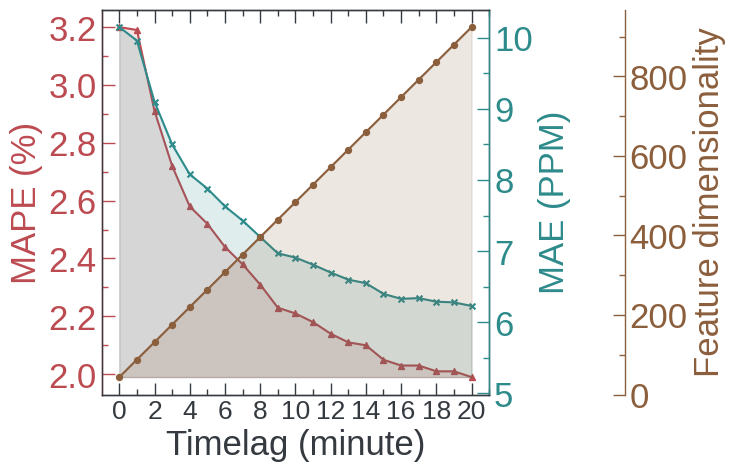

In [58]:
mae_emission = error_df['mae_nox'].to_list()
mape_emission = error_df['mape_nox'].to_list()

w =1 
lw = 1.5
alpha_fill = 0.15
matplotlib.rcParams['axes.linewidth'] = w
fig, ax = plt.subplots(figsize=(5, 5))
s = 25
sz = 18
x = list(range(0,21,1))
_= plt.scatter(x, mape_emission, color = col1, marker = '^', s = sz, label = '$R^{2}_{train}$')
_= plt.plot(x, mape_emission, color = col1, lw = lw, ls = 'solid')
_= plt.fill_between(x, mape_emission,  min(mape_emission), color=col1, alpha= alpha_fill) 

_=plt.tick_params(axis = 'y', which = 'both', left = 'True', color = col1, width = w, direction = 'in')
_=plt.tick_params(axis = 'x', which = 'both', width = w, top = True, bottom = True, direction = 'in')
_=plt.tick_params(axis = 'both', which = 'major', length = 9)
_=plt.tick_params(axis = 'both', which = 'minor', length = 4)
_= ax.yaxis.set_minor_locator(AutoMinorLocator(2))
_= ax.xaxis.set_minor_locator(AutoMinorLocator(2))

_=plt.yticks( fontsize=s, fontweight= 'normal', color = col1)
_=plt.xticks( list(range(0,21,2)), fontsize= 19, fontweight= 'normal')

_= plt.ylabel( 'MAPE (%)', fontsize= s, fontweight = 'normal', color = col1)
_= plt.xlabel( 'Timelag (minute)', fontsize= s, fontweight = 'normal')

ax.patch.set_visible(False)  
ax.spines['left'].set_visible(True)
ax.spines['left'].set_edgecolor(col1)
ax.spines['left'].set_linewidth(1)

_=ax2 = ax.twinx()
plt.scatter(x, mae_emission, color = col2, marker = 'x', s = sz, label = 'MAE')
_= plt.plot(x, mae_emission, color = col2, lw = lw, ls = 'solid')
_= plt.fill_between(x, mae_emission, min(mae_emission)-1, color=col2, alpha= alpha_fill) 

_=plt.tick_params(axis = 'y', which = 'both', right = 'True', color = col2, width = w, direction = 'in')
_=plt.tick_params(axis = 'x', which = 'both', width = w, direction = 'in')
_=plt.tick_params(axis = 'both', which = 'major', length = 9)
_=plt.tick_params(axis = 'both', which = 'minor', length = 4)
_= ax2.yaxis.set_minor_locator(AutoMinorLocator(2))
_= ax2.xaxis.set_minor_locator(AutoMinorLocator(2))

_=plt.yticks( fontsize=s, fontweight= 'normal', color = col2)
_=ax2.set_frame_on(True)
_=ax2.patch.set_visible(False)
_=plt.setp(ax2.spines.values(), visible=False)
_=ax2.spines["right"].set_visible(True)
_=ax2.yaxis.label.set_color(col2)
_=ax2.spines["right"].set_edgecolor(col2)
_= plt.ylabel( 'MAE (PPM)', fontsize= s, fontweight = 'normal', color = col2)
# _= plt.title( '$NO_{x}$', fontsize= s, fontweight = 'normal')

ax3 = ax.twinx()
# shift the third axis spine further right so it doesn't overlap ax2
_= ax3.spines["right"].set_position(("axes", 1.35))  
_= ax3.spines["right"].set_edgecolor(col3)

_= plt.scatter(x, model_input_dimensions, color= col3, marker="o", s=sz, label="DF Size")
_= plt.plot(x, model_input_dimensions, color= col3, lw=lw, ls="solid")
_= plt.fill_between(x, model_input_dimensions, min(model_input_dimensions), color=col3, alpha= alpha_fill) 

_=plt.tick_params(axis = 'y', which = 'both', right = 'True', color = col3, width = w, direction = 'in')
_=plt.tick_params(axis = 'x', which = 'both', width = w, direction = 'in')
_=plt.tick_params(axis = 'both', which = 'major', length = 9)
_=plt.tick_params(axis = 'both', which = 'minor', length = 4)
_= ax3.yaxis.set_minor_locator(AutoMinorLocator(2))
_= ax3.xaxis.set_minor_locator(AutoMinorLocator(2))
_=plt.yticks( fontsize=s, fontweight= 'normal', color = col3)
_= ax3.set_ylabel("Feature dimensionality", fontsize=s, fontweight="normal", color= col3)

fig_path="/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/Predict/nox/timelag_error_nox.pdf"
_= plt.savefig(fig_path, bbox_inches='tight', transparent = True, dpi = 1000)  
plt.show()

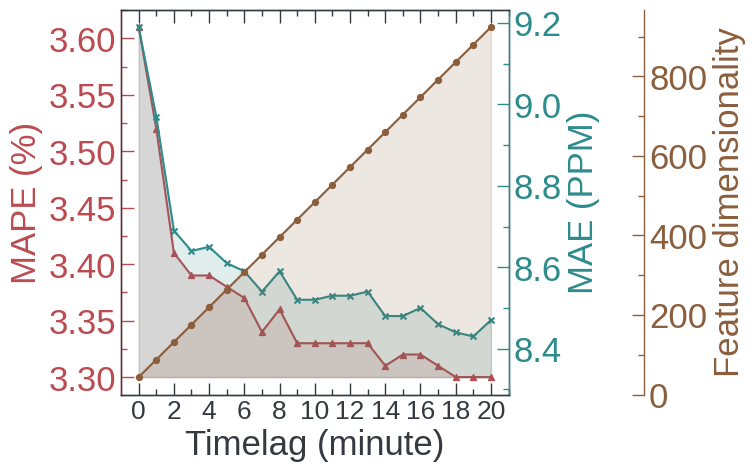

In [59]:
mae_emission = error_df['mae_co'].to_list()
mape_emission = error_df['mape_co'].to_list()
w =1 
lw = 1.5
alpha_fill = 0.15
matplotlib.rcParams['axes.linewidth'] = w
fig, ax = plt.subplots(figsize=(5, 5))
s = 25
sz = 18
x = list(range(0,21,1))
_= plt.scatter(x, mape_emission, color = col1, marker = '^', s = sz, label = '$R^{2}_{train}$')
_= plt.plot(x, mape_emission, color = col1, lw = lw, ls = 'solid')
_= plt.fill_between(x, mape_emission,  min(mape_emission), color=col1, alpha= alpha_fill) 

_=plt.tick_params(axis = 'y', which = 'both', left = 'True', color = col1, width = w, direction = 'in')
_=plt.tick_params(axis = 'x', which = 'both', width = w, top = True, bottom = True, direction = 'in')
_=plt.tick_params(axis = 'both', which = 'major', length = 9)
_=plt.tick_params(axis = 'both', which = 'minor', length = 4)
_= ax.yaxis.set_minor_locator(AutoMinorLocator(2))
_= ax.xaxis.set_minor_locator(AutoMinorLocator(2))

_=plt.yticks( fontsize=s, fontweight= 'normal', color = col1)
_=plt.xticks( list(range(0,21,2)), fontsize= 19, fontweight= 'normal')

_= plt.ylabel( 'MAPE (%)', fontsize= s, fontweight = 'normal', color = col1)
_= plt.xlabel( 'Timelag (minute)', fontsize= s, fontweight = 'normal')

ax.patch.set_visible(False)  
ax.spines['left'].set_visible(True)
ax.spines['left'].set_edgecolor(col1)
ax.spines['left'].set_linewidth(1)

_=ax2 = ax.twinx()
plt.scatter(x, mae_emission, color = col2, marker = 'x', s = sz, label = 'MAE')
_= plt.plot(x, mae_emission, color = col2, lw = lw, ls = 'solid')
_= plt.fill_between(x, mae_emission, min(mae_emission)-0.1, color=col2, alpha= alpha_fill) 

_=plt.tick_params(axis = 'y', which = 'both', right = 'True', color = col2, width = w, direction = 'in')
_=plt.tick_params(axis = 'x', which = 'both', width = w, direction = 'in')
_=plt.tick_params(axis = 'both', which = 'major', length = 9)
_=plt.tick_params(axis = 'both', which = 'minor', length = 4)
_= ax2.yaxis.set_minor_locator(AutoMinorLocator(2))
_= ax2.xaxis.set_minor_locator(AutoMinorLocator(2))

_=plt.yticks( fontsize=s, fontweight= 'normal', color = col2)
_=ax2.set_frame_on(True)
_=ax2.patch.set_visible(False)
_=plt.setp(ax2.spines.values(), visible=False)
_=ax2.spines["right"].set_visible(True)
_=ax2.yaxis.label.set_color(col2)
_=ax2.spines["right"].set_edgecolor(col2)
_= plt.ylabel( 'MAE (PPM)', fontsize= s, fontweight = 'normal', color = col2)
# _= plt.title( '$NO_{x}$', fontsize= s, fontweight = 'normal')

ax3 = ax.twinx()
# shift the third axis spine further right so it doesn't overlap ax2
_= ax3.spines["right"].set_position(("axes", 1.35))  
_= ax3.spines["right"].set_edgecolor(col3)

_= plt.scatter(x, model_input_dimensions, color= col3, marker="o", s=sz, label="DF Size")
_= plt.plot(x, model_input_dimensions, color= col3, lw=lw, ls="solid")
_= plt.fill_between(x, model_input_dimensions, min(model_input_dimensions), color=col3, alpha= alpha_fill) 

_=plt.tick_params(axis = 'y', which = 'both', right = 'True', color = col3, width = w, direction = 'in')
_=plt.tick_params(axis = 'x', which = 'both', width = w, direction = 'in')
_=plt.tick_params(axis = 'both', which = 'major', length = 9)
_=plt.tick_params(axis = 'both', which = 'minor', length = 4)
_= ax3.yaxis.set_minor_locator(AutoMinorLocator(2))
_= ax3.xaxis.set_minor_locator(AutoMinorLocator(2))
_=plt.yticks( fontsize=s, fontweight= 'normal', color = col3)
_= ax3.set_ylabel("Feature dimensionality", fontsize=s, fontweight="normal", color= col3)

fig_path="/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/Predict/co/timelag_error_co.pdf"
_= plt.savefig(fig_path, bbox_inches='tight', transparent = True, dpi = 1000)  
plt.show()

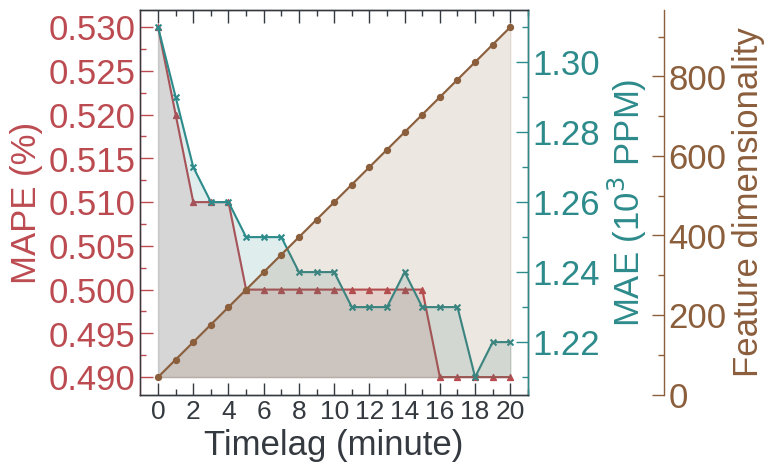

In [61]:
mae_emission = error_df['mae_co2'].to_list()
mape_emission = error_df['mape_co2'].to_list()
w =1 
lw = 1.5
alpha_fill = 0.15
matplotlib.rcParams['axes.linewidth'] = w
fig, ax = plt.subplots(figsize=(5, 5))
s = 25
sz = 18
x = list(range(0,21,1))
_= plt.scatter(x, mape_emission, color = col1, marker = '^', s = sz, label = '$R^{2}_{train}$')
_= plt.plot(x, mape_emission, color = col1, lw = lw, ls = 'solid')
_= plt.fill_between(x, mape_emission,  min(mape_emission), color=col1, alpha= alpha_fill) 

_=plt.tick_params(axis = 'y', which = 'both', left = 'True', color = col1, width = w, direction = 'in')
_=plt.tick_params(axis = 'x', which = 'both', width = w, top = True, bottom = True, direction = 'in')
_=plt.tick_params(axis = 'both', which = 'major', length = 9)
_=plt.tick_params(axis = 'both', which = 'minor', length = 4)
_= ax.yaxis.set_minor_locator(AutoMinorLocator(2))
_= ax.xaxis.set_minor_locator(AutoMinorLocator(2))

_=plt.yticks( fontsize=s, fontweight= 'normal', color = col1)
_=plt.xticks( list(range(0,21,2)), fontsize= 19, fontweight= 'normal')

_= plt.ylabel( 'MAPE (%)', fontsize= s, fontweight = 'normal', color = col1)
_= plt.xlabel( 'Timelag (minute)', fontsize= s, fontweight = 'normal')

ax.patch.set_visible(False)  
ax.spines['left'].set_visible(True)
ax.spines['left'].set_edgecolor(col1)
ax.spines['left'].set_linewidth(1)

_=ax2 = ax.twinx()
plt.scatter(x, mae_emission, color = col2, marker = 'x', s = sz, label = 'MAE')
_= plt.plot(x, mae_emission, color = col2, lw = lw, ls = 'solid')
_= plt.fill_between(x, mae_emission, min(mae_emission)-0.0, color=col2, alpha= alpha_fill) 

_=plt.tick_params(axis = 'y', which = 'both', right = 'True', color = col2, width = w, direction = 'in')
_=plt.tick_params(axis = 'x', which = 'both', width = w, direction = 'in')
_=plt.tick_params(axis = 'both', which = 'major', length = 9)
_=plt.tick_params(axis = 'both', which = 'minor', length = 4)
_= ax2.yaxis.set_minor_locator(AutoMinorLocator(2))
_= ax2.xaxis.set_minor_locator(AutoMinorLocator(2))

_=plt.yticks( fontsize=s, fontweight= 'normal', color = col2)
_=ax2.set_frame_on(True)
_=ax2.patch.set_visible(False)
_=plt.setp(ax2.spines.values(), visible=False)
_=ax2.spines["right"].set_visible(True)
_=ax2.yaxis.label.set_color(col2)
_=ax2.spines["right"].set_edgecolor(col2)
_= plt.ylabel( 'MAE (10$^{3}$ PPM)', fontsize= s, fontweight = 'normal', color = col2)
# _= plt.title( '$NO_{x}$', fontsize= s, fontweight = 'normal')

ax3 = ax.twinx()
# shift the third axis spine further right so it doesn't overlap ax2
_= ax3.spines["right"].set_position(("axes", 1.35))  
_= ax3.spines["right"].set_edgecolor(col3)

_= plt.scatter(x, model_input_dimensions, color= col3, marker="o", s=sz, label="DF Size")
_= plt.plot(x, model_input_dimensions, color= col3, lw=lw, ls="solid")
_= plt.fill_between(x, model_input_dimensions, min(model_input_dimensions), color=col3, alpha= alpha_fill) 

_=plt.tick_params(axis = 'y', which = 'both', right = 'True', color = col3, width = w, direction = 'in')
_=plt.tick_params(axis = 'x', which = 'both', width = w, direction = 'in')
_=plt.tick_params(axis = 'both', which = 'major', length = 9)
_=plt.tick_params(axis = 'both', which = 'minor', length = 4)
_= ax3.yaxis.set_minor_locator(AutoMinorLocator(2))
_= ax3.xaxis.set_minor_locator(AutoMinorLocator(2))
_=plt.yticks( fontsize=s, fontweight= 'normal', color = col3)
_= ax3.set_ylabel("Feature dimensionality", fontsize=s, fontweight="normal", color= col3)

fig_path="/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/Predict/co2/timelag_error_co2.pdf"
_= plt.savefig(fig_path, bbox_inches='tight', transparent = True, dpi = 1000)  
plt.show()

# Making Plots

# load data (NO Ts)

In [ ]:
np.random.seed(1002)
random.seed(0)

#nox
df_filtered_quantile = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/filtered_quantile.pkl')
ALL = df_filtered_quantile.copy(deep = True)
ALL = ALL[(ALL['NOx content in the raw gas (preheater outlet)'] >= 90) & (ALL['NOx content in the raw gas (preheater outlet)'] <= 1000)]
X= ALL.iloc[:,4:]  # -6 for no timeseries, -1 for timeseries
##################################################################### remove nestor's unreliable params
X.drop(['Exit temperature from each preheater cyclone (Stage 5)',
'Flue gas outlet temperature (calciner outlet)',
'Flue gas O2 content (calciner outlet)',
'Clinker outlet temperature'], axis = 1, inplace = True)
y2 = ALL.loc[:,['NOx content in the raw gas (preheater outlet)']]
print(f'Datapoints test-train split = {len(X)}')
y = y2
_, X_no_ts_nox, y_nox_train, y_nox= train_test_split(X,y,test_size=0.20,random_state=0)


# co
total_filter = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/total_filter_co.pkl')
ALL = total_filter.copy(deep = True)
ALL = ALL[(ALL['CO content in the raw gas (preheater outlet)'] > 0) & (ALL['CO content in the raw gas (preheater outlet)'] < 800)]
X= ALL.iloc[:,4:]  # -6 for no timeseries, -1 for timeseries
y = ALL.loc[:,['CO content in the raw gas (preheater outlet)']]
_, X_no_ts_co, y_co_train, y_co= train_test_split(X,y,test_size=0.20,random_state=0)


# co2
total_filter = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/total_filter_co.pkl')
ALL = total_filter.copy(deep = True)
ALL = ALL[(ALL['CO2 content in the raw gas (preheater outlet)'] > 200) & (ALL['CO2 content in the raw gas (preheater outlet)'] < 350)]
X= ALL.iloc[:,4:]  # -6 for no timeseries, -1 for timeseries
y = ALL.loc[:,['CO2 content in the raw gas (preheater outlet)']]
_, X_no_ts_co2, y_co2_train, y_co2= train_test_split(X,y,test_size=0.20,random_state=0)

Datapoints test-train split = 277079


### load data (TS)

In [ ]:
np.random.seed(1002)
random.seed(0)

#nox
lagged_df_nox = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/lag_noxdf_20min.pkl')
ALL = lagged_df_nox.copy(deep = True)
ALL = ALL[(ALL['NOx content in the raw gas (preheater outlet)'] >= 90) & (ALL['NOx content in the raw gas (preheater outlet)'] <= 1000)]
X= ALL.iloc[:,5:]  # -6 for no timeseries, -1 for timeseries
y = ALL.loc[:,['NOx content in the raw gas (preheater outlet)']]
X_ts_nox_train , X_ts_nox, _, _ = train_test_split(X,y,test_size=0.20,random_state=0)

# co
lagged_df_co = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/lag_co_df_20min.pkl')
ALL = lagged_df_co.copy(deep = True)
ALL = ALL[(ALL['CO content in the raw gas (preheater outlet)'] > 0) & (ALL['CO content in the raw gas (preheater outlet)'] < 800)] 
X= ALL.iloc[:,5:]  # -6 for no timeseries, -1 for timeseries
y = ALL.loc[:,['CO content in the raw gas (preheater outlet)']]
X_ts_co_train, X_ts_co, _, _ = train_test_split(X,y,test_size=0.20,random_state=0)

#co2
lagged_df_co2 = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/lag_co2df_20min.pkl')
ALL = lagged_df_co2.copy(deep = True)
ALL = ALL[(ALL['CO2 content in the raw gas (preheater outlet)'] > 200) & (ALL['CO2 content in the raw gas (preheater outlet)'] < 350)]
X= ALL.iloc[:,5:]  # -6 for no timeseries, -1 for timeseries
y = ALL.loc[:,['CO2 content in the raw gas (preheater outlet)']]
X_ts_co2_train, X_ts_co2, _, _ = train_test_split(X,y,test_size=0.20,random_state=0)

# Avg Error metrics for for TS seed models

In [2]:
preds_mean_df_nox = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/prediction_mean_std_nox_TS.pkl')
preds_mean_df_co = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/prediction_mean_std_co_TS.pkl')
preds_mean_df_co2 = pd.read_pickle( '/home/m3rg2000/Junaid_temporary/saved_data/general/prediction_mean_std_co2_TS.pkl')

In [3]:
preds_mean_df_nox

,actual_train,mean_pred_train,std_pred_train,actual_test,mean_pred_test,std_pred_test
0,304.73,308.361694,0.814057,408.67,404.024414,1.066454
1,318.43,307.806122,1.377817,202.33,205.103943,1.476400
2,381.75,377.363220,0.747457,308.89,290.431030,3.283745
3,328.75,330.299225,0.463217,301.88,301.301727,1.065714
4,321.52,345.397980,1.734488,281.05,276.910980,0.778733
...,...,...,...,...,...,...
221658,279.20,282.205505,2.587197,NaN,NaN,NaN
221659,300.28,302.100098,0.843869,NaN,NaN,NaN
221660,397.56,393.004669,0.812045,NaN,NaN,NaN
221661,313.74,310.713867,0.801909,NaN,NaN,NaN


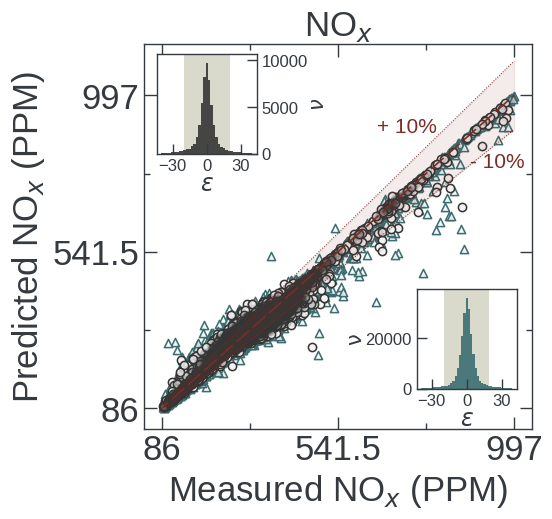

In [38]:
test_actual, train_actual, train_pred, test_pred, y = get_vals(preds_mean_df_nox)
parity_train_test_no_model('NO$_{x}$', 'NO$_{x}$ (PPM)', train_actual, test_actual, train_pred,test_pred, y, fig_path="/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/General_figs/General/ts_train_test_nox.pdf")

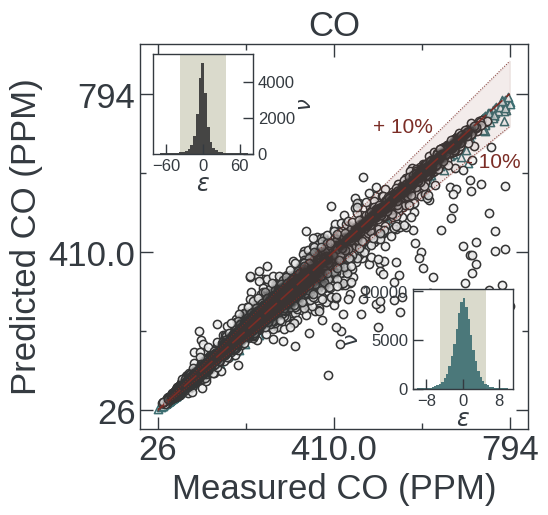

In [39]:
test_actual, train_actual, train_pred, test_pred, y = get_vals(preds_mean_df_co)
parity_train_test_no_model('CO', 'CO (PPM)', train_actual, test_actual, train_pred,test_pred, y, fig_path="/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/General_figs/General/ts_train_test_co.pdf")

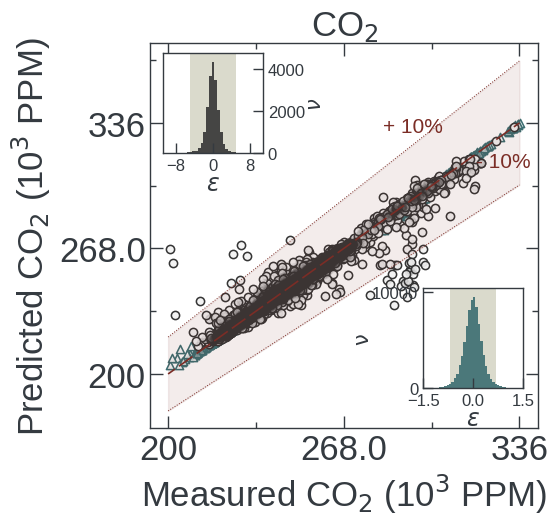

In [40]:
test_actual, train_actual, train_pred, test_pred, y = get_vals(preds_mean_df_co2)
parity_train_test_no_model('CO$_{2}$', 'CO$_{2}$ (10$^3$ PPM)', train_actual, test_actual, train_pred,test_pred, y, fig_path="/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/General_figs/General/ts_train_test_co2.pdf")

In [9]:
seeds_plant1_nox_Ts = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/seeds_plant1_nox_TS.pkl')
seeds_plant1_co_Ts = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/seeds_plant1_co_TS.pkl')
seeds_plant1_co2_Ts = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/seeds_plant1_co2_TS.pkl')

In [6]:
df = seeds_plant1_nox_Ts.copy()
mean_row = np.round(df.mean(),2)
std_row = np.round(df.std(),3)
mean_row.name = 'mean'
std_row.name = 'std'
pd.concat([df, pd.DataFrame([mean_row, std_row])], axis=0)

,r2 train,r2 test,mae train,mae test,mape train,mape test
0,0.971,0.969,5.852,6.191,1.869,1.981
1,0.971,0.969,5.871,6.216,1.875,1.990
2,0.971,0.969,5.891,6.240,1.881,1.997
3,0.971,0.969,5.855,6.185,1.871,1.980
4,0.971,0.969,5.894,6.223,1.882,1.992
5,0.971,0.969,5.865,6.209,1.873,1.989
6,0.971,0.969,5.906,6.242,1.887,1.999
7,0.971,0.969,5.903,6.228,1.885,1.995
8,0.971,0.970,5.817,6.158,1.858,1.971
9,0.971,0.969,5.906,6.241,1.886,1.998


# Generate Avg prediction (dont run again, load saved preds directly)

### NO Ts models

In [ ]:
backbone_nox = pd.DataFrame(columns=list(range(1, 11)))
backbone_co = pd.DataFrame(columns=list(range(1, 11)))
backbone_co2 = pd.DataFrame(columns=list(range(1, 11)))

for seeds in tqdm(range(1, 11)):
    model_nox = load_model(f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/nox/seeds_plant1/nox{seeds}.pkl')
    model_co = load_model(f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/co/seeds_plant1/co{seeds}.pkl')
    model_co2 = load_model(f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/co2/seeds_plant1/co2_{seeds}.pkl')
    
    y_nox_pred = model_nox.predict(X_no_ts_nox)
    y_co_pred = model_co.predict(X_no_ts_co)
    y_co2_pred = model_co2.predict(X_no_ts_co2)
    
    # Assign predictions to the right column
    backbone_nox[seeds] = y_nox_pred
    backbone_co[seeds] = y_co_pred
    backbone_co2[seeds] = y_co2_pred

# Add mean and std columns
backbone_nox["mean"] = backbone_nox.mean(axis=1)
backbone_nox["std"] = backbone_nox.std(axis=1)

backbone_co["mean"] = backbone_co.mean(axis=1)
backbone_co["std"] = backbone_co.std(axis=1)

backbone_co2["mean"] = backbone_co2.mean(axis=1)
backbone_co2["std"] = backbone_co2.std(axis=1)

# Mean predictions
y_nox_no_ts = backbone_nox['mean'].to_list()
y_co_no_ts = backbone_co['mean'].to_list()
y_co2_no_ts = backbone_co2['mean'].to_list()

# Stds
std_nox_no_ts = backbone_nox['std'].to_list()
std_co_no_ts = backbone_co['std'].to_list()
std_co2_no_ts = backbone_co2['std'].to_list()

### TS models

In [ ]:
backbone_nox = pd.DataFrame(columns=list(range(0, 16)))
backbone_co = pd.DataFrame(columns=list(range(0, 16)))
backbone_co2 = pd.DataFrame(columns=list(range(0, 16)))

for seeds in tqdm(range(0, 16)):
    model_nox = load_model(f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/TS_seeds/nox/{seeds}.pkl')
    model_co = load_model(f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/TS_seeds/co/{seeds}.pkl')
    model_co2 = load_model(f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/TS_seeds/co2/{seeds}.pkl')
    
    y_nox_pred = model_nox.predict(X_ts_nox)
    y_co_pred = model_co.predict(X_ts_co)
    y_co2_pred = model_co2.predict(X_ts_co2)
    
    # Assign predictions to the right column
    backbone_nox[seeds] = y_nox_pred
    backbone_co[seeds] = y_co_pred
    backbone_co2[seeds] = y_co2_pred

# Add mean and std columns
backbone_nox["mean"] = backbone_nox.mean(axis=1)
backbone_nox["std"] = backbone_nox.std(axis=1)

backbone_co["mean"] = backbone_co.mean(axis=1)
backbone_co["std"] = backbone_co.std(axis=1)

backbone_co2["mean"] = backbone_co2.mean(axis=1)
backbone_co2["std"] = backbone_co2.std(axis=1)

y_nox_ts = backbone_nox['mean'].to_list()
y_co_ts = backbone_co['mean'].to_list()
y_co2_ts = backbone_co2['mean'].to_list()

std_nox_ts = backbone_nox['std'].to_list()
std_co_ts = backbone_co['std'].to_list()
std_co2_ts = backbone_co2['std'].to_list()

100%|██████████| 16/16 [03:52<00:00, 14.55s/it]


In [ ]:
mean_pred_nox = pd.DataFrame({'no ts':y_nox_no_ts,
                              'ts' : y_nox_ts,
                              'std no ts': std_nox_no_ts ,
                              'std ts': std_nox_ts
                              })

mean_pred_co = pd.DataFrame({'no ts':y_co_no_ts,
                              'ts' : y_co_ts,
                              'std no ts': std_co_no_ts ,
                              'std ts': std_co_ts
                              })

mean_pred_co2 = pd.DataFrame({'no ts':y_co2_no_ts,
                              'ts' : y_co2_ts,
                              'std no ts': std_co2_no_ts ,
                              'std ts': std_co2_ts
                              })


### Save avg predictions

In [ ]:
# mean_pred_nox.to_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/mean_pred_nox_plant1.pkl')
# mean_pred_co.to_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/mean_pred_co_plant1.pkl')
# mean_pred_co2.to_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/mean_pred_co2_plant1.pkl')

### Read avg prdictions

In [8]:
mean_pred_nox = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/mean_pred_nox_plant1.pkl')
mean_pred_co = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/mean_pred_co_plant1.pkl')
mean_pred_co2 = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/mean_pred_co2_plant1.pkl')

std_factor = 3
mean_pred_nox['std no ts'] = mean_pred_nox['std no ts'] * std_factor
mean_pred_nox['std ts'] = mean_pred_nox['std ts'] * std_factor

mean_pred_co['std no ts'] = mean_pred_co['std no ts'] * std_factor
mean_pred_co['std ts'] = mean_pred_co['std ts'] * std_factor

mean_pred_co2['std no ts'] = mean_pred_co2['std no ts'] * std_factor
mean_pred_co2['std ts'] = mean_pred_co2['std ts'] * std_factor

# get value of lists for plotting
y_nox_no_ts = mean_pred_nox['no ts'].to_list()
y_nox_ts = mean_pred_nox['ts'].to_list()
std_nox_no_ts = mean_pred_nox['std no ts'].to_list()
std_nox_ts = mean_pred_nox['std ts'].to_list()

y_co_no_ts = mean_pred_co['no ts'].to_list()
y_co_ts = mean_pred_co['ts'].to_list()
std_co_no_ts = mean_pred_co['std no ts'].to_list()
std_co_ts = mean_pred_co['std ts'].to_list()

y_co2_no_ts = mean_pred_co2['no ts'].to_list()
y_co2_ts = mean_pred_co2['ts'].to_list()
std_co2_no_ts = mean_pred_co2['std no ts'].to_list()
std_co2_ts = mean_pred_co2['std ts'].to_list()

### Parity plot (mean predictions)

 0.84 17.71 5.65
 0.97 6.1 1.95


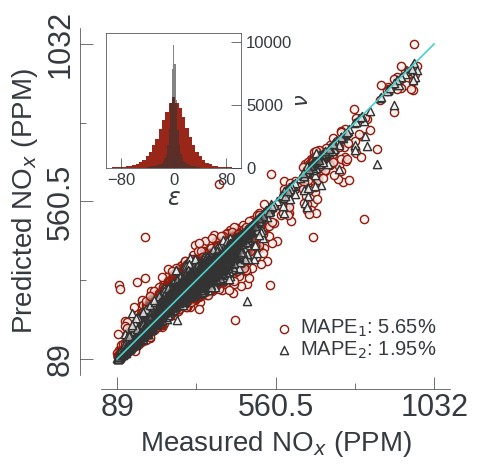

 0.98 9.21 3.61
 0.98 8.25 3.21


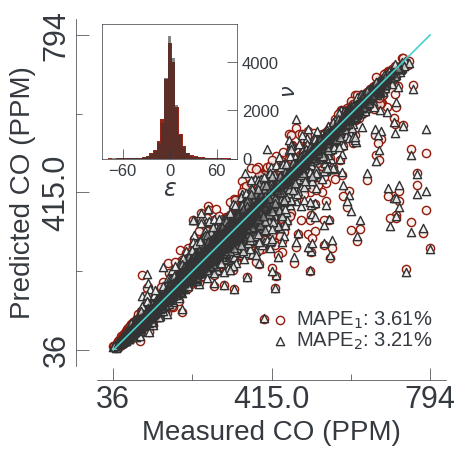

 0.96 1.29 0.52
 0.96 1.15 0.46


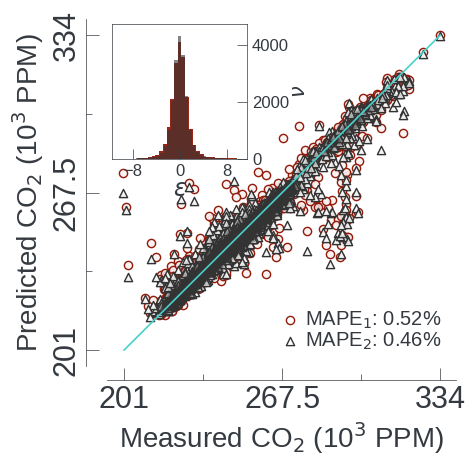

In [23]:
parity_test1_test2('NO$_{x}$ (PPM)',y_nox, y_nox_no_ts, y_nox_ts, fig_path="/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/General_figs/General/parity_ts_no_ts_nox.pdf")
parity_test1_test2('CO (PPM)',y_co, y_co_no_ts, y_co_ts, fig_path="/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/General_figs/General/parity_ts_no_ts_co.pdf")
parity_test1_test2('CO$_{2}$ (10$^{3}$ PPM)',y_co2, y_co2_no_ts, y_co2_ts, fig_path="/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/General_figs/General/parity_ts_no_ts_co2.pdf")

# Prepare data for Timeline plot

### Read computed dataframes

In [ ]:
# Combined df has avg predictioins of the seed models. Std vals have been multiplied by 3
combined = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/general/combined_avg_predictions.pkl')
nox_df = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/general/nox_df_avg_pred.pkl')
co_df = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/general/co_df_avg_pred.pkl')
co2_df = pd.read_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/general/co2_df_avg_pred.pkl')

### Process the data

In [25]:
combined_no_nan= combined.dropna(axis = 0, how = 'any', inplace = False)   
combined_no_nan.reset_index(inplace=True)
combined_no_nan.drop(columns = ['index'], inplace = True)


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [6]:
# working_windows = get_working_windows(combined_no_nan )
# working_windows 
# # Only 7 consecative values in the combined data frame

### Timeline plot

In [26]:
e = combined_no_nan.copy()
sequence_nox = e['actual nox'].to_list() 
sequence_co = e['actual co'].to_list() 
sequence_co2 = e['actual co2'].to_list() 

dates = e['timestamp'].to_list()   # all dates, no missing date
short_date = [i[0:7] for i in dates]   # taking only year and month
e.insert(0, 'month', short_date, True)   ## adding month to the dataframe. Required for ploting
y = e.drop_duplicates(subset='month', keep='first')
y.reset_index(inplace=True)
index_month = y.loc[:,['index', 'month']]     ##### finding index of 1st month for the dataframe
date_string = [i[:-9] for i in dates]  # Ploted on x axis
index_plot = index_month['index'].to_list()
month_plot = index_month['month'].to_list()

index_month

,index,month
0,0,2020-04
1,9,2020-05
2,39,2020-06
3,124,2020-07
4,156,2020-08
5,165,2021-01
6,211,2021-02
7,302,2021-03
8,500,2021-04
9,592,2021-05


In [27]:
df_plot = combined_no_nan.copy(deep = True)
actual_nox = df_plot['actual nox'].to_list()
no_ts_nox = df_plot['no ts nox'].to_list()
ts_nox = df_plot['ts nox'].to_list()
std_ts_nox = df_plot['std ts nox'].to_list()
std_no_ts_nox = df_plot['std no ts nox'].to_list()

actual_co = df_plot['actual co'].to_list()
no_ts_co = df_plot['no ts co'].to_list()
ts_co = df_plot['ts co'].to_list()
std_ts_co = df_plot['std ts co'].to_list()
std_no_ts_co = df_plot['std no ts co'].to_list()

actual_co2 = df_plot['actual co2'].to_list()
no_ts_co2 = df_plot['no ts co2'].to_list()
ts_co2 = df_plot['ts co2'].to_list()
std_ts_co2 = df_plot['std ts co2'].to_list()
std_no_ts_co2 = df_plot['std no ts co2'].to_list()

In [31]:
# variation of 30 points (half hour) in May 2021
low = 600
high =630
high-low

30

In [29]:
# variation of all points:
low = 0
high = len(actual_co)
high-low

874

# Timeline plots below

In [30]:

plant_data_col = 'mediumturquoise'
# plant_data_col = 'lightseagreen'

# TS
ts_col =    "#000000"
std_ts_col =   "#000000"
std_alpha_ts = 0.1 #0.09

# no TS
no_ts_col = 'red' #'#c1121f' 
std_no_ts_col ="#941b0c"#'#c1121f' #'#8a3033'
std_alpha_no_ts = 0.1

#Error
error_col =  '#708d81'
error_col_edge = '#3c6e71'
error_alpha = 0.3

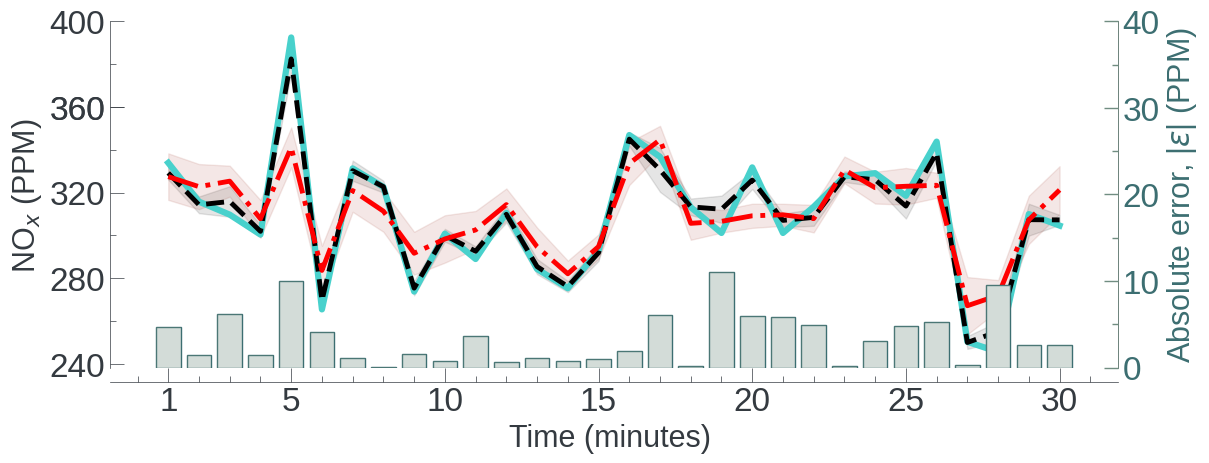

In [36]:
#nox
actual = actual_nox
no_ts_pred = no_ts_nox
ts_pred = ts_nox
std_ts = std_ts_nox
std_no_ts = std_no_ts_nox

ts_std_min = list(np.array(ts_nox) - np.array(std_ts_nox))
ts_std_max = list(np.array(ts_nox) + np.array(std_ts_nox))

no_ts_std_min = list(np.array(no_ts_nox) - np.array(std_no_ts_nox))
no_ts_std_max = list(np.array(no_ts_nox) + np.array(std_no_ts_nox))


x_stamp = []
for i in range(len(df_plot)):
    x_stamp.append(i)

x =               x_stamp[low:high]
y_actual =             actual[low:high]      
y_no_ts_pred =              no_ts_pred[low:high]  
y_ts_pred =              ts_pred[low:high]  
y_ts_std_min = ts_std_min[low:high]
y_ts_std_max = ts_std_max[low:high]
y_no_ts_std_min = no_ts_std_min[low:high]
y_no_ts_std_max = no_ts_std_max[low:high]
errors = [abs(y_actual[i] - y_ts_pred[i]) for i in range(len(y_ts_pred))]   

fig, ax = plt.subplots(figsize=(13, 4.5))  
_= ax.spines['top'].set_visible(False)
_= ax.spines['left'].set_position(('outward', 0))
_= ax.spines['bottom'].set_position(('outward', 10))
s = 24
w = 0.5

_= plt.plot(x,y_actual, color = plant_data_col,linewidth=4.5, label = 'Ground truth', zorder = 3)
_= plt.plot(x,y_ts_pred, color = ts_col,linewidth=3.5 , label= 'ML'+' '+'model' + '$_{mean}$',ls = '--', zorder = 4) 
_= plt.plot(x,y_no_ts_pred, color = no_ts_col,linewidth=3.5 , label= 'ML'+' '+'model' + '$_{mean}$',ls = 'dashdot', zorder = 4) 

_= plt.fill_between(x, y_ts_std_min,y_ts_std_max, color = std_ts_col, alpha = std_alpha_ts, label = '$\pm$'+' '+ '3'+'$\sigma$') 
_= plt.fill_between(x, y_no_ts_std_min,y_no_ts_std_max, color = std_no_ts_col, alpha = std_alpha_no_ts, label = '$\pm$'+' '+ '3'+'$\sigma$') 

_= plt.xticks([600, 604, 609, 614, 619, 624, 629],[1, 5, 10, 15, 20, 25, 30] ,rotation = 0, fontsize = s) 
_= plt.yticks([240, 280, 320,360, 360, 400], [240, 280, 320,360, 360, 400], rotation = 0, fontsize = s)
_= plt.xticks( fontweight = 'normal', fontsize = s)
_= plt.yticks(fontweight = 'normal', fontsize = s)
_= ax.tick_params('both', length=10, width=w, which='major')
_= ax.tick_params('both', length=4.5, width=w, which='minor')
_= plt.tick_params(axis="both", which="both", direction = 'in', right = True, left = True, top = False)
_= plt.xlabel('Time (minutes) ', fontsize= s-2, fontweight = 'normal')
_= plt.ylabel('NO$_{x}$ (PPM)', fontsize= s-2, fontweight = 'normal')
_= ax.yaxis.set_minor_locator(AutoMinorLocator(2))

_= ax.xaxis.set_minor_locator(MultipleLocator(1))  # at every unit
# _= ax.xaxis.grid(False, linestyle="solid", which = 'both' , color="gray", linewidth=0.5, alpha=0.7, zorder = 2)
# _= ax.set_axisbelow(False)  # gridlines above the bars

_=ax2 = ax.twinx()
_=ax2.patch.set_alpha(0)
l =ax2.bar(x,errors, color = 'white', label = r'|$\epsilon$|', ec =error_col_edge, zorder = -1) 
l =ax2.bar(x,errors, color = error_col, label = r'|$\epsilon$|', alpha = error_alpha, zorder = -1) 
_=ax2.set_ylim(0, 40)
_= plt.yticks([0, 10, 20, 30, 40],[0, 10, 20, 30, 40] ,rotation = 0, fontsize = s) 
_=plt.tick_params(axis = 'y', which = 'both', right = 'True', color = error_col)
_= ax2.tick_params('both', length=10, width=w, which='major', direction = 'in')
_= ax2.tick_params('both', length=4.5, width=w, which='minor', direction = 'in')
_=plt.yticks(fontsize=s, fontweight= 'normal', color = error_col_edge)
_= ax2.yaxis.set_minor_locator(AutoMinorLocator(2))

_=ax2.set_frame_on(True)
_=ax2.patch.set_visible(False)
_=plt.setp(ax2.spines.values(), visible=False)
_=ax2.spines["right"].set_visible(True)
_=ax2.yaxis.label.set_color(error_col)
_=ax2.spines["right"].set_edgecolor(error_col)
_= plt.tick_params( which = 'both', width= 1)
_= plt.ylabel( r'Absolute error, |$\epsilon$| (PPM)', fontsize= s-2, fontweight = 'normal', color = error_col_edge)
fig_path="/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/Predict/nox/TS_nox_predict.pdf"
_= plt.savefig(fig_path, bbox_inches='tight', transparent = True, dpi = 1000)  
plt.show()

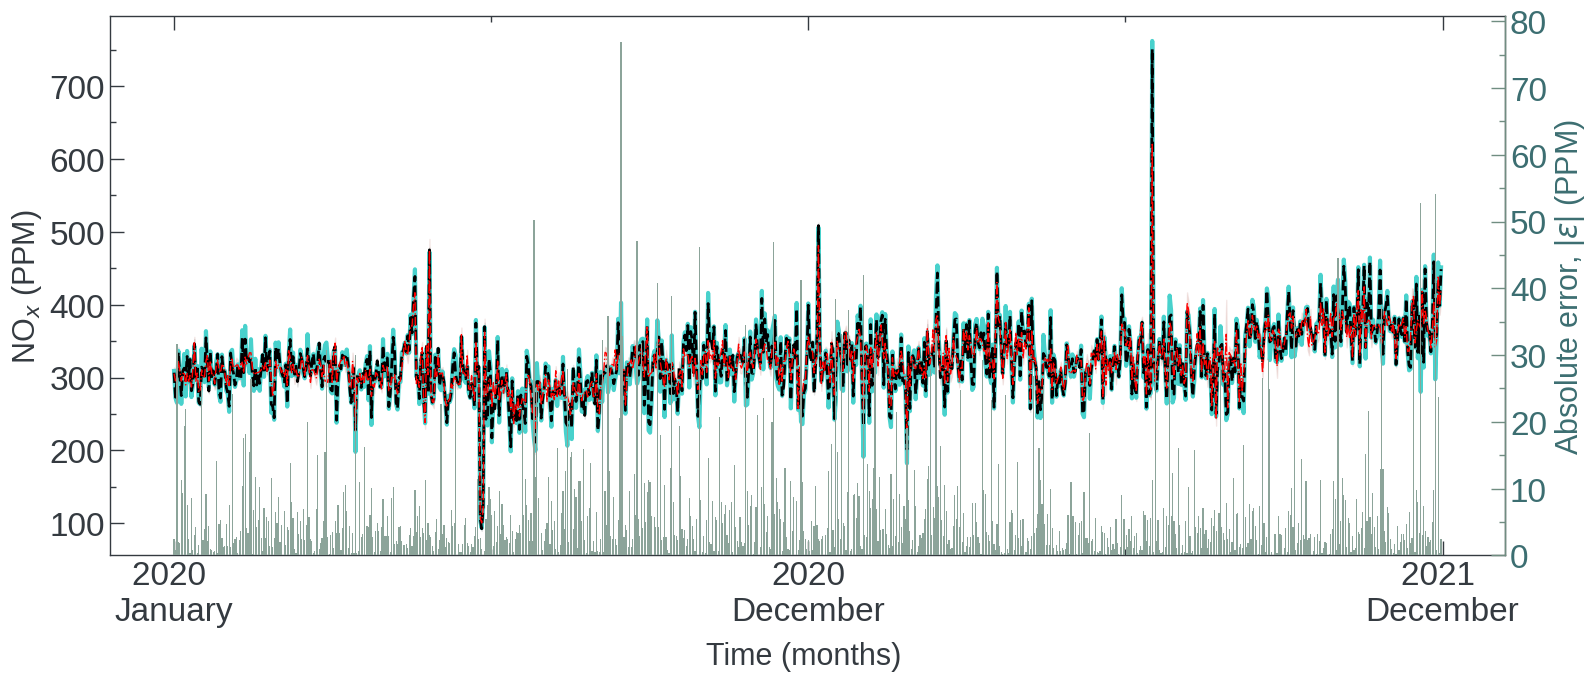

In [38]:
#nox
actual = actual_nox
no_ts_pred = no_ts_nox
ts_pred = ts_nox
std_ts = std_ts_nox
std_no_ts = std_no_ts_nox

ts_std_min = list(np.array(ts_nox) - np.array(std_ts_nox))
ts_std_max = list(np.array(ts_nox) + np.array(std_ts_nox))

no_ts_std_min = list(np.array(no_ts_nox) - np.array(std_no_ts_nox))
no_ts_std_max = list(np.array(no_ts_nox) + np.array(std_no_ts_nox))


x_stamp = []
for i in range(len(df_plot)):
    x_stamp.append(i)

x =               x_stamp[low:high]
y_actual =             actual[low:high]      
y_no_ts_pred =              no_ts_pred[low:high]  
y_ts_pred =              ts_pred[low:high]  
y_ts_std_min = ts_std_min[low:high]
y_ts_std_max = ts_std_max[low:high]
y_no_ts_std_min = no_ts_std_min[low:high]
y_no_ts_std_max = no_ts_std_max[low:high]
errors = [abs(y_actual[i] - y_ts_pred[i]) for i in range(len(y_ts_pred))]   

fig, ax = plt.subplots(figsize=(18,7))  
s = 24
w = 1

_= plt.plot(x,y_actual, color = plant_data_col,linewidth= 3, label = 'Ground truth', zorder = 3)
_= plt.plot(x,y_ts_pred, color = ts_col,linewidth= 2 , label= 'ML'+' '+'model' + '$_{mean}$',ls = '--', zorder = 4) 
_= plt.plot(x,y_no_ts_pred, color = no_ts_col,linewidth= 1 , label= 'ML'+' '+'model' + '$_{mean}$',ls = 'dashdot', zorder = 4) 

_= plt.fill_between(x, y_ts_std_min,y_ts_std_max, color = std_ts_col, alpha = std_alpha_ts, label = '$\pm$'+' '+ '3'+'$\sigma$') 
_= plt.fill_between(x, y_no_ts_std_min,y_no_ts_std_max, color = std_no_ts_col, alpha = std_alpha_no_ts, label = '$\pm$'+' '+ '3'+'$\sigma$') 

_= plt.xticks([0, 437, 874],['2020 \nJanuary','2020\nDecember','2021 \nDecember',] ,rotation = 0, fontsize = s) 
# _= plt.yticks([240, 280, 320,360, 360, 400], [240, 280, 320,360, 360, 400], rotation = 0, fontsize = s)
_= plt.xticks( fontweight = 'normal', fontsize = s)
_= plt.yticks(fontweight = 'normal', fontsize = s)
_= ax.tick_params('both', length=10, width=w, which='major')
_= ax.tick_params('both', length=4.5, width=w, which='minor')
_= plt.tick_params(axis="both", which="both", direction = 'in', right = True, left = True, top = True)
_= plt.xlabel('Time (months) ', fontsize= s-2, fontweight = 'normal', labelpad= 10)
_= plt.ylabel('NO$_{x}$ (PPM)', fontsize= s-2, fontweight = 'normal')
_= ax.yaxis.set_minor_locator(AutoMinorLocator(2))

_= ax.xaxis.set_minor_locator(AutoMinorLocator(2)) 
# _= ax.xaxis.grid(True, linestyle="solid", which = 'both' , color="gray", linewidth=0.5, alpha=0.7, zorder = 2)
# _= ax.set_axisbelow(False)  # gridlines above the bars

_=ax2 = ax.twinx()
_=ax2.patch.set_alpha(0)
l =ax2.bar(x,errors, color = 'white', label = r'|$\epsilon$|', ec =None, zorder = -1) 
l =ax2.bar(x,errors, color = error_col, label = r'|$\epsilon$|', alpha = error_alpha+0.5, zorder = -1) 
# _=ax2.set_ylim(0, 40)
# _= plt.yticks([0, 10, 20, 30, 40],[0, 10, 20, 30, 40] ,rotation = 0, fontsize = s) 
_=plt.tick_params(axis = 'y', which = 'both', right = 'True', color = error_col)
_= ax2.tick_params('both', length=10, width=w, which='major', direction = 'in')
_= ax2.tick_params('both', length=4.5, width=w, which='minor', direction = 'in')
_=plt.yticks(fontsize=s, fontweight= 'normal', color = error_col_edge)
_= ax2.yaxis.set_minor_locator(AutoMinorLocator(2))

_=ax2.set_frame_on(True)
_=ax2.patch.set_visible(False)
_=plt.setp(ax2.spines.values(), visible=False)
_=ax2.spines["right"].set_visible(True)
_=ax2.yaxis.label.set_color(error_col)
_=ax2.spines["right"].set_edgecolor(error_col)
_= plt.tick_params( which = 'both', width= 1)
_= plt.ylabel( r'Absolute error, |$\epsilon$| (PPM)', fontsize= s-2, fontweight = 'normal', color = error_col_edge)
fig_path="/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/Predict/nox/TS_nox_predict_full.pdf"
_= plt.savefig(fig_path, bbox_inches='tight', transparent = True, dpi = 1000)  
plt.show()

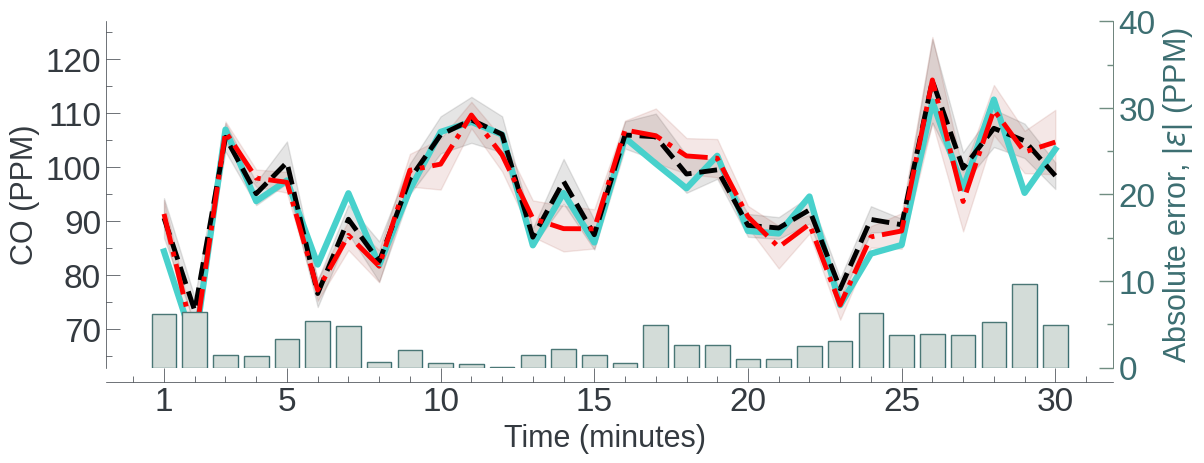

In [37]:
#co
actual = actual_co
no_ts_pred = no_ts_co
ts_pred = ts_co
std_ts = std_ts_co
std_no_ts = std_no_ts_co

ts_std_min = list(np.array(ts_co) - np.array(std_ts_co))
ts_std_max = list(np.array(ts_co) + np.array(std_ts_co))

no_ts_std_min = list(np.array(no_ts_co) - np.array(std_no_ts_co))
no_ts_std_max = list(np.array(no_ts_co) + np.array(std_no_ts_co))

x_stamp = []
for i in range(len(df_plot)):
    x_stamp.append(i)

x =               x_stamp[low:high]
y_actual =             actual[low:high]      
y_no_ts_pred =              no_ts_pred[low:high]  
y_ts_pred =              ts_pred[low:high]  
y_ts_std_min = ts_std_min[low:high]
y_ts_std_max = ts_std_max[low:high]
y_no_ts_std_min = no_ts_std_min[low:high]
y_no_ts_std_max = no_ts_std_max[low:high]
errors = [abs(y_actual[i] - y_ts_pred[i]) for i in range(len(y_ts_pred))]   

fig, ax = plt.subplots(figsize=(13, 4.5))  
_= ax.spines['top'].set_visible(False)
_= ax.spines['left'].set_position(('outward', 0))
_= ax.spines['bottom'].set_position(('outward', 10))
s = 24
w = 0.5

_= plt.plot(x,y_actual, color = plant_data_col,linewidth=4.5, label = 'Ground truth', zorder = 3)
_= plt.plot(x,y_ts_pred, color = ts_col,linewidth=3.5 , label= 'ML'+' '+'model' + '$_{mean}$',ls = '--', zorder = 4) 
_= plt.plot(x,y_no_ts_pred, color = no_ts_col,linewidth=3.5 , label= 'ML'+' '+'model' + '$_{mean}$',ls = 'dashdot', zorder = 4) 

_= plt.fill_between(x, y_ts_std_min,y_ts_std_max, color = std_ts_col, alpha = std_alpha_ts, label = '$\pm$'+' '+ '3'+'$\sigma$') 
_= plt.fill_between(x, y_no_ts_std_min,y_no_ts_std_max, color = std_no_ts_col, alpha = std_alpha_no_ts, label = '$\pm$'+' '+ '3'+'$\sigma$') 

_= plt.xticks([600, 604, 609, 614, 619, 624, 629],[1, 5, 10, 15, 20, 25, 30] ,rotation = 0, fontsize = s) 
_= plt.yticks(rotation = 0, fontsize = s)
_= plt.xticks( fontweight = 'normal', fontsize = s)
_= plt.yticks(fontweight = 'normal', fontsize = s)
_= ax.tick_params('both', length=10, width=w, which='major')
_= ax.tick_params('both', length=4.5, width=w, which='minor')
_= plt.tick_params(axis="both", which="both", direction = 'in', right = True, left = True, top = False)
_= plt.xlabel('Time (minutes) ', fontsize= s-2, fontweight = 'normal')
_= plt.ylabel('CO (PPM)', fontsize= s-2, fontweight = 'normal')
_= ax.yaxis.set_minor_locator(AutoMinorLocator(2))

_= ax.xaxis.set_minor_locator(MultipleLocator(1))  # at every unit
# _= ax.xaxis.grid(True, linestyle="solid", which = 'both' , color="gray", linewidth=0.5, alpha=0.7, zorder = 2)
# _= ax.set_axisbelow(False)  # gridlines above the bars

# _= ax.minorticks_on()

_=ax2 = ax.twinx()
_=ax2.patch.set_alpha(0)
l =ax2.bar(x,errors, color = 'white', label = r'|$\epsilon$|', ec =error_col_edge, zorder = -1) 
l =ax2.bar(x,errors, color = error_col, label = r'|$\epsilon$|', alpha = error_alpha, zorder = -1) 
_=ax2.set_ylim(0, 40)

_=plt.tick_params(axis = 'y', which = 'both', right = 'True', color = error_col)
_= ax2.tick_params('both', length=10, width=w, which='major', direction = 'in')
_= ax2.tick_params('both', length=4.5, width=w, which='minor', direction = 'in')
_=plt.yticks(fontsize=s, fontweight= 'normal', color = error_col_edge)
_= ax2.yaxis.set_minor_locator(AutoMinorLocator(2))
_= plt.yticks([0, 10, 20, 30, 40],[0, 10, 20, 30, 40] ,rotation = 0, fontsize = s) 

_=ax2.set_frame_on(True)
_=ax2.patch.set_visible(False)
_=plt.setp(ax2.spines.values(), visible=False)
_=ax2.spines["right"].set_visible(True)
_=ax2.yaxis.label.set_color(error_col)
_=ax2.spines["right"].set_edgecolor(error_col)
_= plt.tick_params( which = 'both', width= 1)
_= plt.ylabel( r'Absolute error, |$\epsilon$| (PPM)', fontsize= s-2, fontweight = 'normal', color = error_col_edge)
fig_path="/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/Predict/co/TS_co_predict.pdf"
_= plt.savefig(fig_path, bbox_inches='tight', transparent = True, dpi = 1000)  
plt.show()

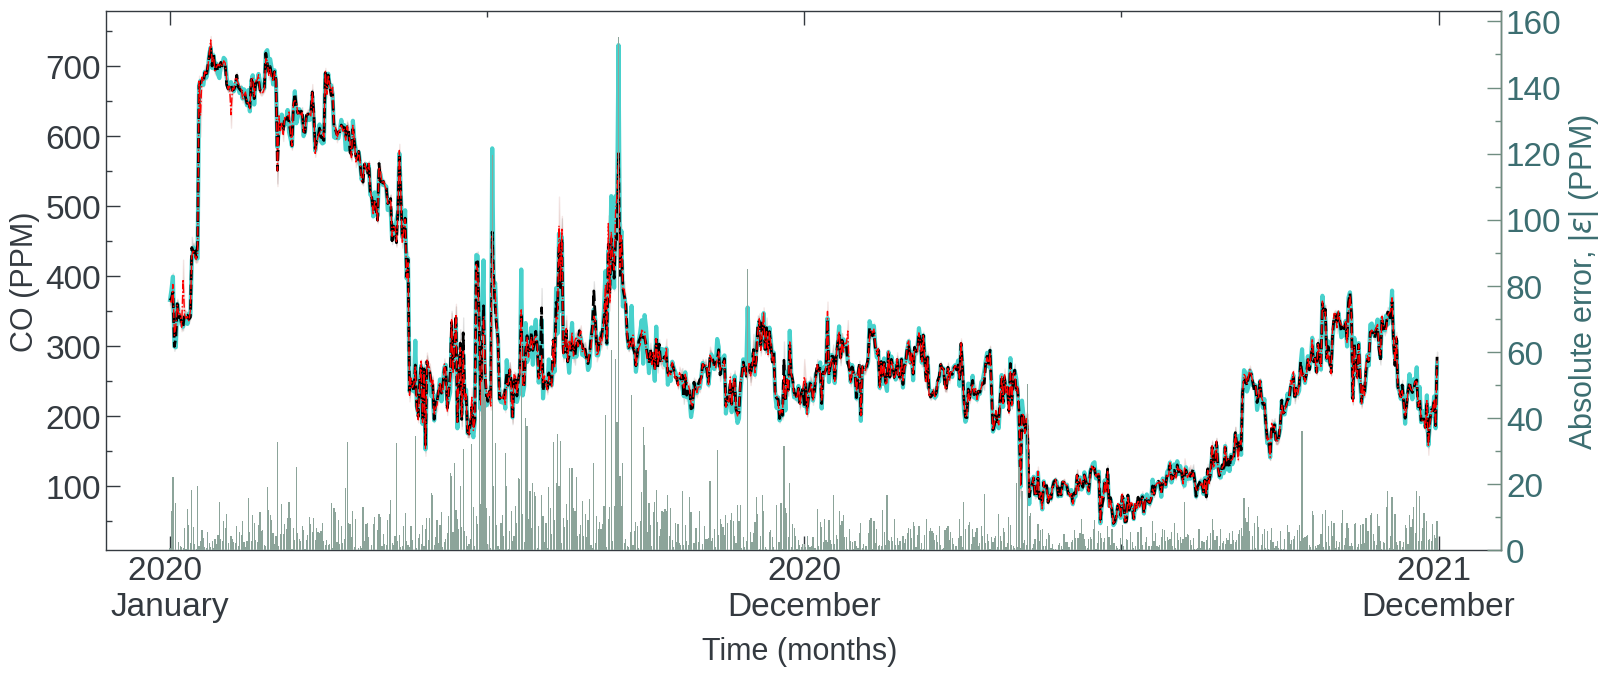

In [ ]:
#co
actual = actual_co
no_ts_pred = no_ts_co
ts_pred = ts_co
std_ts = std_ts_co
std_no_ts = std_no_ts_co

ts_std_min = list(np.array(ts_co) - np.array(std_ts_co))
ts_std_max = list(np.array(ts_co) + np.array(std_ts_co))

no_ts_std_min = list(np.array(no_ts_co) - np.array(std_no_ts_co))
no_ts_std_max = list(np.array(no_ts_co) + np.array(std_no_ts_co))

x_stamp = []
for i in range(len(df_plot)):
    x_stamp.append(i)

x =               x_stamp[low:high]
y_actual =             actual[low:high]      
y_no_ts_pred =              no_ts_pred[low:high]  
y_ts_pred =              ts_pred[low:high]  
y_ts_std_min = ts_std_min[low:high]
y_ts_std_max = ts_std_max[low:high]
y_no_ts_std_min = no_ts_std_min[low:high]
y_no_ts_std_max = no_ts_std_max[low:high]
errors = [abs(y_actual[i] - y_ts_pred[i]) for i in range(len(y_ts_pred))]   

fig, ax = plt.subplots(figsize=(18,7))   
s = 24
w = 1

_= plt.plot(x,y_actual, color = plant_data_col,linewidth=3, label = 'Ground truth', zorder = 3)
_= plt.plot(x,y_ts_pred, color = ts_col,linewidth=2 , label= 'ML'+' '+'model' + '$_{mean}$',ls = '--', zorder = 4) 
_= plt.plot(x,y_no_ts_pred, color = no_ts_col,linewidth=1 , label= 'ML'+' '+'model' + '$_{mean}$',ls = 'dashdot', zorder = 4) 

_= plt.fill_between(x, y_ts_std_min,y_ts_std_max, color = std_ts_col, alpha = std_alpha_ts, label = '$\pm$'+' '+ '3'+'$\sigma$') 
_= plt.fill_between(x, y_no_ts_std_min,y_no_ts_std_max, color = std_no_ts_col, alpha = std_alpha_no_ts, label = '$\pm$'+' '+ '3'+'$\sigma$') 

_= plt.xticks([0, 437, 874],['2020 \nJanuary','2020\nDecember','2021 \nDecember',] ,rotation = 0, fontsize = s) 
# _= plt.yticks(rotation = 0, fontsize = s)
_= plt.xticks( fontweight = 'normal', fontsize = s)
_= plt.yticks(fontweight = 'normal', fontsize = s)
_= ax.tick_params('both', length=10, width=w, which='major')
_= ax.tick_params('both', length=4.5, width=w, which='minor')
_= plt.tick_params(axis="both", which="both", direction = 'in', right = True, left = True, top = False)
_= plt.xlabel('Time (months) ', fontsize= s-2, fontweight = 'normal', labelpad= 10)
_= plt.ylabel('CO (PPM)', fontsize= s-2, fontweight = 'normal')
_= ax.yaxis.set_minor_locator(AutoMinorLocator(2))

_= ax.xaxis.set_minor_locator(AutoMinorLocator(2))
# _= ax.xaxis.grid(True, linestyle="solid", which = 'both' , color="gray", linewidth=0.5, alpha=0.7, zorder = 2)
# _= ax.set_axisbelow(False)  # gridlines above the bars

# _= ax.minorticks_on()

_=ax2 = ax.twinx()
_=ax2.patch.set_alpha(0)
l =ax2.bar(x,errors, color = 'white', label = r'|$\epsilon$|', ec =None, zorder = -1) 
l =ax2.bar(x,errors, color = error_col, label = r'|$\epsilon$|', alpha = error_alpha+0.5, zorder = -1) 
# _=ax2.set_ylim(0, 40)

_=plt.tick_params(axis = 'y', which = 'both', right = 'True', color = error_col)
_= ax2.tick_params('both', length=10, width=w, which='major', direction = 'in')
_= ax2.tick_params('both', length=4.5, width=w, which='minor', direction = 'in')
_=plt.yticks(fontsize=s, fontweight= 'normal', color = error_col_edge)
_= ax2.yaxis.set_minor_locator(AutoMinorLocator(2))
# _= plt.yticks([0, 10, 20, 30, 40],[0, 10, 20, 30, 40] ,rotation = 0, fontsize = s) 

_=ax2.set_frame_on(True)
_=ax2.patch.set_visible(False)
_=plt.setp(ax2.spines.values(), visible=False)
_=ax2.spines["right"].set_visible(True)
_=ax2.yaxis.label.set_color(error_col)
_=ax2.spines["right"].set_edgecolor(error_col)
_= plt.tick_params( which = 'both', width= 1)
_= plt.ylabel( r'Absolute error, |$\epsilon$| (PPM)', fontsize= s-2, fontweight = 'normal', color = error_col_edge)
fig_path="/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/Predict/co/TS_co_predict_full.pdf"
_= plt.savefig(fig_path, bbox_inches='tight', transparent = True, dpi = 1000)  
plt.show()

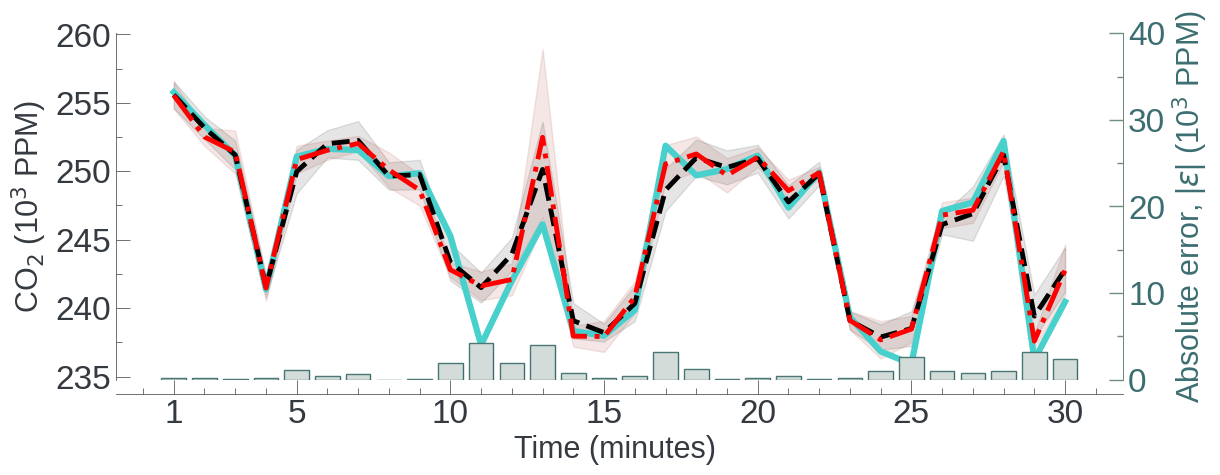

In [38]:
#co2
actual = actual_co2
no_ts_pred = no_ts_co2
ts_pred = ts_co2
std_ts = std_ts_co2
std_no_ts = std_no_ts_co2

ts_std_min = list(np.array(ts_co2) - np.array(std_ts_co2))
ts_std_max = list(np.array(ts_co2) + np.array(std_ts_co2))

no_ts_std_min = list(np.array(no_ts_co2) - np.array(std_no_ts_co2))
no_ts_std_max = list(np.array(no_ts_co2) + np.array(std_no_ts_co2))


x_stamp = []
for i in range(len(df_plot)):
    x_stamp.append(i)

x =               x_stamp[low:high]
y_actual =             actual[low:high]      
y_no_ts_pred =              no_ts_pred[low:high]  
y_ts_pred =              ts_pred[low:high]  
y_ts_std_min = ts_std_min[low:high]
y_ts_std_max = ts_std_max[low:high]
y_no_ts_std_min = no_ts_std_min[low:high]
y_no_ts_std_max = no_ts_std_max[low:high]
errors = [abs(y_actual[i] - y_ts_pred[i]) for i in range(len(y_ts_pred))]   

fig, ax = plt.subplots(figsize=(13, 4.5))  
_= ax.spines['top'].set_visible(False)
_= ax.spines['left'].set_position(('outward', 0))
_= ax.spines['bottom'].set_position(('outward', 10))
s = 24
w = 0.5

_= plt.plot(x,y_actual, color = plant_data_col,linewidth=4.5, label = 'Ground truth', zorder = 3)
_= plt.plot(x,y_ts_pred, color = ts_col,linewidth=3.5 , label= 'ML'+' '+'model' + '$_{mean}$',ls = '--', zorder = 4) 
_= plt.plot(x,y_no_ts_pred, color = no_ts_col,linewidth=3.5 , label= 'ML'+' '+'model' + '$_{mean}$',ls = 'dashdot', zorder = 4) 

_= plt.fill_between(x, y_ts_std_min,y_ts_std_max, color = std_ts_col, alpha = std_alpha_ts, label = '$\pm$'+' '+ '3'+'$\sigma$') 
_= plt.fill_between(x, y_no_ts_std_min,y_no_ts_std_max, color = std_no_ts_col, alpha = std_alpha_no_ts, label = '$\pm$'+' '+ '3'+'$\sigma$') 

_= plt.xticks([600, 604, 609, 614, 619, 624, 629],[1, 5, 10, 15, 20, 25, 30] ,rotation = 0, fontsize = s) 
_= plt.yticks([235, 240, 245, 250, 255, 260],[235, 240, 245, 250, 255, 260], rotation = 0, fontsize = s)
_= plt.xticks( fontweight = 'normal', fontsize = s)
_= plt.yticks(fontweight = 'normal', fontsize = s)
_= ax.tick_params('both', length=10, width=w, which='major')
_= ax.tick_params('both', length=4.5, width=w, which='minor')
_= plt.tick_params(axis="both", which="both", direction = 'in', right = True, left = True, top = False)
_= plt.xlabel('Time (minutes) ', fontsize= s-2, fontweight = 'normal')
_= plt.ylabel('CO$_{2}$ (10$^{3}$ PPM)', fontsize= s-2, fontweight = 'normal')
_= ax.yaxis.set_minor_locator(AutoMinorLocator(2))

_= ax.xaxis.set_minor_locator(MultipleLocator(1))  # at every unit
# _= ax.xaxis.grid(True, linestyle="solid", which = 'both' , color="gray", linewidth=0.5, alpha=0.7, zorder = 2)
# _= ax.set_axisbelow(False)  # gridlines above the bars

_=ax2 = ax.twinx()
_=ax2.patch.set_alpha(0)
l =ax2.bar(x,errors, color = 'white', label = r'|$\epsilon$|', ec =error_col_edge, zorder = -1) 
l =ax2.bar(x,errors, color = error_col, label = r'|$\epsilon$|', alpha = error_alpha, zorder = -1) 
_=ax2.set_ylim(0, 40)
_= plt.yticks([0, 10, 20, 30, 40],[0, 10, 20, 30, 40] ,rotation = 0, fontsize = s) 
_=plt.tick_params(axis = 'y', which = 'both', right = 'True', color = error_col)
_= ax2.tick_params('both', length=10, width=w, which='major', direction = 'in')
_= ax2.tick_params('both', length=4.5, width=w, which='minor', direction = 'in')
_=plt.yticks(fontsize=s, fontweight= 'normal', color = error_col_edge)
_= ax2.yaxis.set_minor_locator(AutoMinorLocator(2))

_=ax2.set_frame_on(True)
_=ax2.patch.set_visible(False)
_=plt.setp(ax2.spines.values(), visible=False)
_=ax2.spines["right"].set_visible(True)
_=ax2.yaxis.label.set_color(error_col)
_=ax2.spines["right"].set_edgecolor(error_col)
_= plt.tick_params( which = 'both', width= 1)
_= plt.ylabel( r'Absolute error, |$\epsilon$| (10$^{3}$ PPM)', fontsize= s-2, fontweight = 'normal', color = error_col_edge)
fig_path="/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/Predict/co2/TS_co2_predict.pdf"
_= plt.savefig(fig_path, bbox_inches='tight', transparent = True, dpi = 1000)  
plt.show()

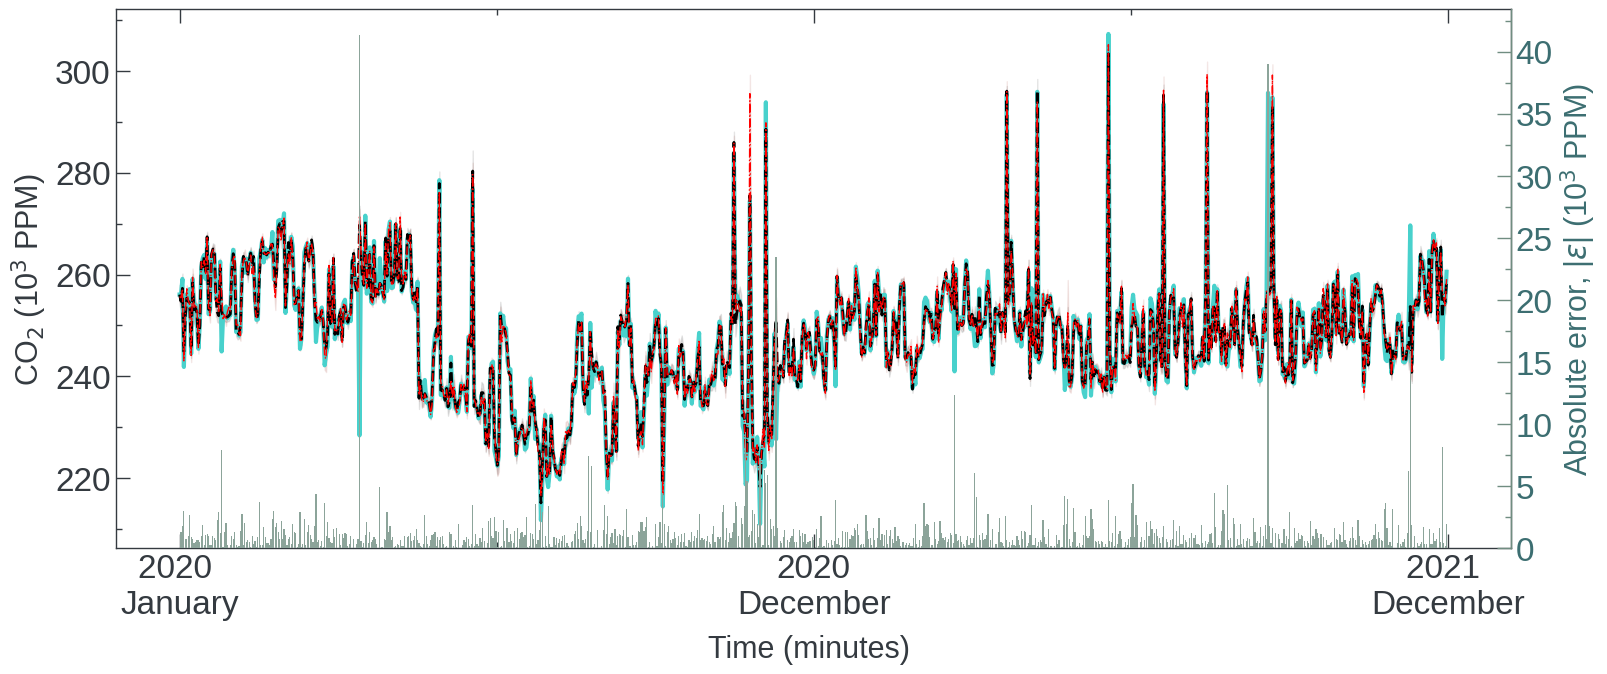

In [ ]:
#co2
actual = actual_co2
no_ts_pred = no_ts_co2
ts_pred = ts_co2
std_ts = std_ts_co2
std_no_ts = std_no_ts_co2

ts_std_min = list(np.array(ts_co2) - np.array(std_ts_co2))
ts_std_max = list(np.array(ts_co2) + np.array(std_ts_co2))

no_ts_std_min = list(np.array(no_ts_co2) - np.array(std_no_ts_co2))
no_ts_std_max = list(np.array(no_ts_co2) + np.array(std_no_ts_co2))


x_stamp = []
for i in range(len(df_plot)):
    x_stamp.append(i)

x =               x_stamp[low:high]
y_actual =             actual[low:high]      
y_no_ts_pred =              no_ts_pred[low:high]  
y_ts_pred =              ts_pred[low:high]  
y_ts_std_min = ts_std_min[low:high]
y_ts_std_max = ts_std_max[low:high]
y_no_ts_std_min = no_ts_std_min[low:high]
y_no_ts_std_max = no_ts_std_max[low:high]
errors = [abs(y_actual[i] - y_ts_pred[i]) for i in range(len(y_ts_pred))]   

fig, ax = plt.subplots(figsize=(18,7))  
s = 24
w = 1

_= plt.plot(x,y_actual, color = plant_data_col,linewidth=3, label = 'Ground truth', zorder = 3)
_= plt.plot(x,y_ts_pred, color = ts_col,linewidth=2 , label= 'ML'+' '+'model' + '$_{mean}$',ls = '--', zorder = 4) 
_= plt.plot(x,y_no_ts_pred, color = no_ts_col,linewidth=1 , label= 'ML'+' '+'model' + '$_{mean}$',ls = 'dashdot', zorder = 4) 

_= plt.fill_between(x, y_ts_std_min,y_ts_std_max, color = std_ts_col, alpha = std_alpha_ts, label = '$\pm$'+' '+ '3'+'$\sigma$') 
_= plt.fill_between(x, y_no_ts_std_min,y_no_ts_std_max, color = std_no_ts_col, alpha = std_alpha_no_ts, label = '$\pm$'+' '+ '3'+'$\sigma$') 

plt.axvline(x=1, color='red', linestyle='--', linewidth=1.5)
plt.axvline(x=3, color='blue', linestyle='--', linewidth=1.5)

_= plt.xticks([0, 437, 874],['2020 \nJanuary','2020\nDecember','2021 \nDecember',] ,rotation = 0, fontsize = s) 
# _= plt.yticks([235, 240, 245, 250, 255, 260],[235, 240, 245, 250, 255, 260], rotation = 0, fontsize = s)
_= plt.xticks( fontweight = 'normal', fontsize = s)
_= plt.yticks(fontweight = 'normal', fontsize = s)
_= ax.tick_params('both', length=10, width=w, which='major')
_= ax.tick_params('both', length=4.5, width=w, which='minor')
_= plt.tick_params(axis="both", which="both", direction = 'in', right = True, left = True, top = True)
_= plt.xlabel('Time (minutes) ', fontsize= s-2, fontweight = 'normal', labelpad= 10)
_= plt.ylabel('CO$_{2}$ (10$^{3}$ PPM)', fontsize= s-2, fontweight = 'normal')
_= ax.yaxis.set_minor_locator(AutoMinorLocator(2))

_= ax.xaxis.set_minor_locator(AutoMinorLocator(2))
# _= ax.xaxis.grid(True, linestyle="solid", which = 'both' , color="gray", linewidth=0.5, alpha=0.7, zorder = 2)
# _= ax.set_axisbelow(False)  # gridlines above the bars

_=ax2 = ax.twinx()
_=ax2.patch.set_alpha(0)
l =ax2.bar(x,errors, color = 'white', label = r'|$\epsilon$|', ec =None, zorder = -1) 
l =ax2.bar(x,errors, color = error_col, label = r'|$\epsilon$|', alpha = error_alpha + 0.5, zorder = -1) 
# _=ax2.set_ylim(0, 40)
# _= plt.yticks([0, 10, 20, 30, 40],[0, 10, 20, 30, 40] ,rotation = 0, fontsize = s) 
_=plt.tick_params(axis = 'y', which = 'both', right = 'True', color = error_col)
_= ax2.tick_params('both', length=10, width=w, which='major', direction = 'in')
_= ax2.tick_params('both', length=4.5, width=w, which='minor', direction = 'in')
_=plt.yticks(fontsize=s, fontweight= 'normal', color = error_col_edge)
_= ax2.yaxis.set_minor_locator(AutoMinorLocator(2))

_=ax2.set_frame_on(True)
_=ax2.patch.set_visible(False)
_=plt.setp(ax2.spines.values(), visible=False)
_=ax2.spines["right"].set_visible(True)
_=ax2.yaxis.label.set_color(error_col)
_=ax2.spines["right"].set_edgecolor(error_col)
_= plt.tick_params( which = 'both', width= 1)
_= plt.ylabel( r'Absolute error, |$\epsilon$| (10$^{3}$ PPM)', fontsize= s-2, fontweight = 'normal', color = error_col_edge)
fig_path="/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/Predict/co2/TS_co2_predict_full.pdf"
# _= plt.savefig(fig_path, bbox_inches='tight', transparent = True, dpi = 1000)  
plt.show()

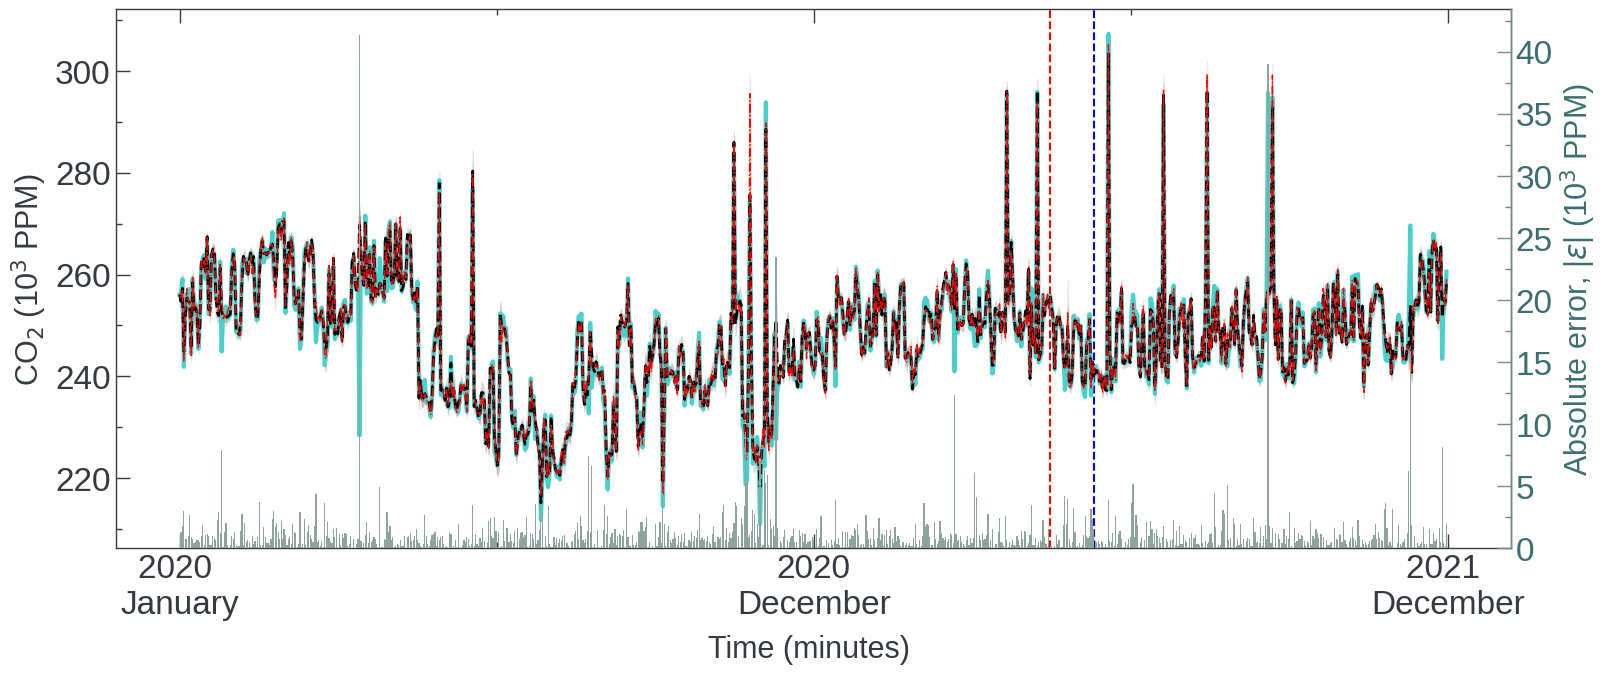

In [41]:
#co2
actual = actual_co2
no_ts_pred = no_ts_co2
ts_pred = ts_co2
std_ts = std_ts_co2
std_no_ts = std_no_ts_co2

ts_std_min = list(np.array(ts_co2) - np.array(std_ts_co2))
ts_std_max = list(np.array(ts_co2) + np.array(std_ts_co2))

no_ts_std_min = list(np.array(no_ts_co2) - np.array(std_no_ts_co2))
no_ts_std_max = list(np.array(no_ts_co2) + np.array(std_no_ts_co2))


x_stamp = []
for i in range(len(df_plot)):
    x_stamp.append(i)

x =               x_stamp[low:high]
y_actual =             actual[low:high]      
y_no_ts_pred =              no_ts_pred[low:high]  
y_ts_pred =              ts_pred[low:high]  
y_ts_std_min = ts_std_min[low:high]
y_ts_std_max = ts_std_max[low:high]
y_no_ts_std_min = no_ts_std_min[low:high]
y_no_ts_std_max = no_ts_std_max[low:high]
errors = [abs(y_actual[i] - y_ts_pred[i]) for i in range(len(y_ts_pred))]   

fig, ax = plt.subplots(figsize=(18,7))  
s = 24
w = 1

_= plt.plot(x,y_actual, color = plant_data_col,linewidth=3, label = 'Ground truth', zorder = 3)
_= plt.plot(x,y_ts_pred, color = ts_col,linewidth=2 , label= 'ML'+' '+'model' + '$_{mean}$',ls = '--', zorder = 4) 
_= plt.plot(x,y_no_ts_pred, color = no_ts_col,linewidth=1 , label= 'ML'+' '+'model' + '$_{mean}$',ls = 'dashdot', zorder = 4) 

_= plt.fill_between(x, y_ts_std_min,y_ts_std_max, color = std_ts_col, alpha = std_alpha_ts, label = '$\pm$'+' '+ '3'+'$\sigma$') 
_= plt.fill_between(x, y_no_ts_std_min,y_no_ts_std_max, color = std_no_ts_col, alpha = std_alpha_no_ts, label = '$\pm$'+' '+ '3'+'$\sigma$') 

plt.axvline(x= 600, color='red', linestyle='--', linewidth=1.5)
plt.axvline(x= 630, color='blue', linestyle='--', linewidth=1.5)

_= plt.xticks([0, 437, 874],['2020 \nJanuary','2020\nDecember','2021 \nDecember',] ,rotation = 0, fontsize = s) 
# _= plt.yticks([235, 240, 245, 250, 255, 260],[235, 240, 245, 250, 255, 260], rotation = 0, fontsize = s)
_= plt.xticks( fontweight = 'normal', fontsize = s)
_= plt.yticks(fontweight = 'normal', fontsize = s)
_= ax.tick_params('both', length=10, width=w, which='major')
_= ax.tick_params('both', length=4.5, width=w, which='minor')
_= plt.tick_params(axis="both", which="both", direction = 'in', right = True, left = True, top = True)
_= plt.xlabel('Time (minutes) ', fontsize= s-2, fontweight = 'normal', labelpad= 10)
_= plt.ylabel('CO$_{2}$ (10$^{3}$ PPM)', fontsize= s-2, fontweight = 'normal')
_= ax.yaxis.set_minor_locator(AutoMinorLocator(2))

_= ax.xaxis.set_minor_locator(AutoMinorLocator(2))
# _= ax.xaxis.grid(True, linestyle="solid", which = 'both' , color="gray", linewidth=0.5, alpha=0.7, zorder = 2)
# _= ax.set_axisbelow(False)  # gridlines above the bars

_=ax2 = ax.twinx()
_=ax2.patch.set_alpha(0)
l =ax2.bar(x,errors, color = 'white', label = r'|$\epsilon$|', ec =None, zorder = -1) 
l =ax2.bar(x,errors, color = error_col, label = r'|$\epsilon$|', alpha = error_alpha + 0.5, zorder = -1) 
# _=ax2.set_ylim(0, 40)
# _= plt.yticks([0, 10, 20, 30, 40],[0, 10, 20, 30, 40] ,rotation = 0, fontsize = s) 
_=plt.tick_params(axis = 'y', which = 'both', right = 'True', color = error_col)
_= ax2.tick_params('both', length=10, width=w, which='major', direction = 'in')
_= ax2.tick_params('both', length=4.5, width=w, which='minor', direction = 'in')
_=plt.yticks(fontsize=s, fontweight= 'normal', color = error_col_edge)
_= ax2.yaxis.set_minor_locator(AutoMinorLocator(2))

_=ax2.set_frame_on(True)
_=ax2.patch.set_visible(False)
_=plt.setp(ax2.spines.values(), visible=False)
_=ax2.spines["right"].set_visible(True)
_=ax2.yaxis.label.set_color(error_col)
_=ax2.spines["right"].set_edgecolor(error_col)
_= plt.tick_params( which = 'both', width= 1)
_= plt.ylabel( r'Absolute error, |$\epsilon$| (10$^{3}$ PPM)', fontsize= s-2, fontweight = 'normal', color = error_col_edge)
fig_path="/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/Predict/co2/TS_co2_predict_full.pdf"
# _= plt.savefig(fig_path, bbox_inches='tight', transparent = True, dpi = 1000)  
plt.show()

# models sizes

In [6]:
model_size('/home/m3rg2000/Junaid_temporary/saved_models/general_models/NOx_Ts.pkl')
model_size('/home/m3rg2000/Junaid_temporary/saved_models/general_models/CO_Ts.pkl')
model_size('/home/m3rg2000/Junaid_temporary/saved_models/general_models/CO2_Ts.pkl')

Model size: 89.17 MB
Model size: 45.56 MB
Model size: 34.33 MB


### Generating Cobmined Avg prediction (Dont run again, just read directly)

In [ ]:

mean_pred_nox = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/mean_pred_nox_plant1.pkl')
mean_pred_co = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/mean_pred_co_plant1.pkl')
mean_pred_co2 = pd.read_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/mean_pred_co2_plant1.pkl')

std_factor = 3
mean_pred_nox['std no ts'] = mean_pred_nox['std no ts'] * std_factor
mean_pred_nox['std ts'] = mean_pred_nox['std ts'] * std_factor

mean_pred_co['std no ts'] = mean_pred_co['std no ts'] * std_factor
mean_pred_co['std ts'] = mean_pred_co['std ts'] * std_factor

mean_pred_co2['std no ts'] = mean_pred_co2['std no ts'] * std_factor
mean_pred_co2['std ts'] = mean_pred_co2['std ts'] * std_factor


y_nox.reset_index(inplace=True)
y_nox.rename(columns = {'index':'no_missing'}, inplace = True)

y_co.reset_index(inplace=True)
y_co.rename(columns = {'index':'no_missing'}, inplace = True)

y_co2.reset_index(inplace=True)
y_co2.rename(columns = {'index':'no_missing'}, inplace = True)


# index of total_filter and df_filtered_quantile is the same as no_missing
nox_df = pd.concat([y_nox,mean_pred_nox ], axis = 1)
nox_df.columns.values[1] = "actual nox"
nox_df.columns = list(nox_df.columns[:2]) + [col + " nox" for col in nox_df.columns[2:]]
nox_df.sort_values(by='no_missing', inplace = True)

co_df = pd.concat([y_co,mean_pred_co ], axis = 1)
co_df.columns.values[1] = "actual co"
co_df.columns = list(co_df.columns[:2]) + [col + " co" for col in co_df.columns[2:]]
co_df.sort_values(by='no_missing', inplace = True)

co2_df = pd.concat([y_co2,mean_pred_co2 ], axis = 1)
co2_df.columns.values[1] = "actual co2"
co2_df.columns = list(co2_df.columns[:2]) + [col + " co2" for col in co2_df.columns[2:]]
co2_df.sort_values(by='no_missing', inplace = True)

# c = pd.concat([total_filter, df_merged.loc[:,['no_missing']]])
# c.sort_values(by='no_missing', inplace = True)
# d = nox_df.merge(df_merged[['no_missing','timestamp' ]], on = 'no_missing', how = 'left')
# e1 = d.drop_duplicates(subset='no_missing', keep='first') # no duplices present here
# col = e1.pop('timestamp')
# e1.insert(1, 'timestamp', col)

# d = co_df.merge(df_merged[['no_missing','timestamp' ]], on = 'no_missing', how = 'left')
# e2 = d.drop_duplicates(subset='no_missing', keep='first') # no duplices present here
# col = e2.pop('timestamp')
# e2.insert(1, 'timestamp', col)

# d = co2_df.merge(df_merged[['no_missing','timestamp' ]], on = 'no_missing', how = 'left')
# e3 = d.drop_duplicates(subset='no_missing', keep='first') # no duplices present here
# col = e3.pop('timestamp')
# e3.insert(1, 'timestamp', col)

# Step 1. Merge them on 'no_missing' (outer join)
combined = nox_df.merge(co_df, on="no_missing", how="outer").merge(co2_df, on="no_missing", how="outer")

# Step 2. Find the global min and max of no_missing across all three
min_val = min(nox_df["no_missing"].min(), co_df["no_missing"].min(), co2_df["no_missing"].min())
max_val = max(nox_df["no_missing"].max(), co_df["no_missing"].max(), co2_df["no_missing"].max())

# Step 3. Create full range of no_missing values
full_range = pd.DataFrame({"no_missing": range(min_val, max_val + 1)})

# Step 4. Reindex combined df to include all values in the full range
combined = full_range.merge(combined, on="no_missing", how="left")

# Step 5. Sort by no_missing just in case
combined = combined.sort_values("no_missing").reset_index(drop=True)

# Step 6. Add timestamps
d = combined.merge(df_merged[['no_missing','timestamp' ]], on = 'no_missing', how = 'left')
combined = d.drop_duplicates(subset='no_missing', keep='first') # no duplices present here
col = combined.pop('timestamp')
combined.insert(1, 'timestamp', col)
combined.to_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/general/combined_avg_predictions.pkl')
nox_df.to_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/general/nox_df_avg_pred.pkl')
co_df.to_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/general/co_df_avg_pred.pkl')
co2_df.to_pickle('/media/m3rg2000/mounted/Junaid/.../Emissions/new_emission/Notebooks/Saved_files/data/general/co2_df_avg_pred.pkl')

Dont run the below again

In [ ]:
# NOx
compute_mean_std_predictions(y_nox_train, y_nox, X_ts_nox_train, X_ts_nox,
                             'nox', '/home/m3rg2000/Junaid_temporary/saved_data/general/prediction_mean_std_nox_TS.pkl')

# CO
compute_mean_std_predictions(y_co_train, y_co, X_ts_co_train, X_ts_co,
                             'co', '/home/m3rg2000/Junaid_temporary/saved_data/general/prediction_mean_std_co_TS.pkl')

# CO2
compute_mean_std_predictions(y_co2_train, y_co2, X_ts_co2_train, X_ts_co2,
                             'co2', '/home/m3rg2000/Junaid_temporary/saved_data/general/prediction_mean_std_co2_TS.pkl')

### Read seed models, calculate avg errors (dont run this again)

In [ ]:
# nox TS
ac_ts = y_nox[list(y_nox.columns)[0]].to_list()
ac_tr = y_nox_train[list(y_nox_train.columns)[0]].to_list()

train_r2 = []
train_mae = []
train_mape = []
test_r2 = []
test_mae = []
test_mape = []

for seeds in tqdm(range(0,16)):
    model = load_model(f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/TS_seeds/nox/{seeds}.pkl')
    
    pr_ts = list(model.predict(X_ts_nox))
    pr_tr = list(model.predict(X_ts_nox_train))   
         
    mae = mean_absolute_error(ac_ts,pr_ts).round(3)
    r2 = r2_score(ac_ts,pr_ts).round(3)
    mape = (mean_absolute_percentage_error(ac_ts,pr_ts)*100).round(3)  
    test_r2.append(r2)
    test_mae.append(mae) 
    test_mape.append(mape)
    
    mae = mean_absolute_error(ac_tr,pr_tr).round(3)
    r2 = r2_score(ac_tr,pr_tr).round(3)
    mape = (mean_absolute_percentage_error(ac_tr,pr_tr)*100).round(3)  
    train_r2.append(r2)
    train_mae.append(mae) 
    train_mape.append(mape)
    
metrics = pd.DataFrame({'r2 train': train_r2,'r2 test': test_r2, 'mae train':train_mae, 'mae test':test_mae,'mape train': train_mape, 'mape test': test_mape})
# metrics.to_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/seeds_plant1_nox_TS.pkl') # commented so that no overwriting

# co Ts
ac_ts = y_co[list(y_co.columns)[0]].to_list()
ac_tr = y_co_train[list(y_co_train.columns)[0]].to_list()

train_r2 = []
train_mae = []
train_mape = []
test_r2 = []
test_mae = []
test_mape = []

for seeds in tqdm(range(0,16)):
    model = load_model(f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/TS_seeds/co/{seeds}.pkl')
    
    pr_ts = list(model.predict(X_ts_co))
    pr_tr = list(model.predict(X_ts_co_train))   
         
    mae = mean_absolute_error(ac_ts,pr_ts).round(3)
    r2 = r2_score(ac_ts,pr_ts).round(3)
    mape = (mean_absolute_percentage_error(ac_ts,pr_ts)*100).round(3)  
    test_r2.append(r2)
    test_mae.append(mae) 
    test_mape.append(mape)
    
    mae = mean_absolute_error(ac_tr,pr_tr).round(3)
    r2 = r2_score(ac_tr,pr_tr).round(3)
    mape = (mean_absolute_percentage_error(ac_tr,pr_tr)*100).round(3)  
    train_r2.append(r2)
    train_mae.append(mae) 
    train_mape.append(mape)
    
metrics = pd.DataFrame({'r2 train': train_r2,'r2 test': test_r2, 'mae train':train_mae, 'mae test':test_mae,'mape train': train_mape, 'mape test': test_mape})
# metrics.to_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/seeds_plant1_co_TS.pkl')
    

# co2 Ts
ac_ts = y_co2[list(y_co2.columns)[0]].to_list()
ac_tr = y_co2_train[list(y_co2_train.columns)[0]].to_list()

train_r2 = []
train_mae = []
train_mape = []
test_r2 = []
test_mae = []
test_mape = []

for seeds in tqdm(range(0,16)):
    model = load_model(f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/TS_seeds/co2/{seeds}.pkl')
    
    pr_ts = list(model.predict(X_ts_co2))
    pr_tr = list(model.predict(X_ts_co2_train))   
         
    mae = mean_absolute_error(ac_ts,pr_ts).round(3)
    r2 = r2_score(ac_ts,pr_ts).round(3)
    mape = (mean_absolute_percentage_error(ac_ts,pr_ts)*100).round(3)  
    test_r2.append(r2)
    test_mae.append(mae) 
    test_mape.append(mape)
    
    mae = mean_absolute_error(ac_tr,pr_tr).round(3)
    r2 = r2_score(ac_tr,pr_tr).round(3)
    mape = (mean_absolute_percentage_error(ac_tr,pr_tr)*100).round(3)  
    train_r2.append(r2)
    train_mae.append(mae) 
    train_mape.append(mape)
    
metrics = pd.DataFrame({'r2 train': train_r2,'r2 test': test_r2, 'mae train':train_mae, 'mae test':test_mae,'mape train': train_mape, 'mape test': test_mape})
# metrics.to_pickle('/home/m3rg2000/Junaid_temporary/saved_data/general/seeds_plant1_co2_TS.pkl')

# Supplementary

# Notebook functions

In [35]:
def get_vals(DF):
    df = DF.copy()
    test_actual = pd.Series(df['actual_test'].to_list()).dropna().tolist()
    train_actual = df['actual_train'].to_list()
    train_pred = df['mean_pred_train'].to_list()
    test_pred = pd.Series(df['mean_pred_test'].to_list()).dropna().tolist()
    y = test_actual + train_actual
    return(test_actual, train_actual, train_pred, test_pred, y)

In [13]:
def compute_mean_std_predictions(y_train, y_test, X_train, X_test, gas, save_path):
    ac_ts = y_test[list(y_test.columns)[0]].to_numpy()
    ac_tr = y_train[list(y_train.columns)[0]].to_numpy()

    all_preds_ts = []
    all_preds_tr = []

    for seeds in tqdm(range(0, 15), desc=f"{gas} Models"):   # 15 models
        model = load_model(f'/home/m3rg2000/Junaid_temporary/saved_models/general_models/predict/plant1/TS_seeds/{gas}/{seeds}.pkl')

        pr_ts = model.predict(X_test)
        pr_tr = model.predict(X_train)

        all_preds_ts.append(pr_ts)
        all_preds_tr.append(pr_tr)

    # Convert to arrays of shape (n_models, n_samples)
    all_preds_ts = np.array(all_preds_ts)
    all_preds_tr = np.array(all_preds_tr)

    # Compute mean and std across models (axis=0)
    mean_pred_ts = np.mean(all_preds_ts, axis=0)
    std_pred_ts  = np.std(all_preds_ts, axis=0)
    mean_pred_tr = np.mean(all_preds_tr, axis=0)
    std_pred_tr  = np.std(all_preds_tr, axis=0)

    # Determine max length
    max_len = max(len(ac_tr), len(ac_ts))

    # Pad with NaN so train/test can align in DataFrame
    actual_train_pad = np.concatenate([ac_tr, np.full(max_len - len(ac_tr), np.nan)])
    mean_pred_train_pad = np.concatenate([mean_pred_tr, np.full(max_len - len(ac_tr), np.nan)])
    std_pred_train_pad = np.concatenate([std_pred_tr, np.full(max_len - len(ac_tr), np.nan)])

    actual_test_pad = np.concatenate([ac_ts, np.full(max_len - len(ac_ts), np.nan)])
    mean_pred_test_pad = np.concatenate([mean_pred_ts, np.full(max_len - len(ac_ts), np.nan)])
    std_pred_test_pad = np.concatenate([std_pred_ts, np.full(max_len - len(ac_ts), np.nan)])

    pred_summary = pd.DataFrame({
        'actual_train': actual_train_pad,
        'mean_pred_train': mean_pred_train_pad,
        'std_pred_train': std_pred_train_pad,
        'actual_test': actual_test_pad,
        'mean_pred_test': mean_pred_test_pad,
        'std_pred_test': std_pred_test_pad
    })

    pred_summary.to_pickle(save_path)


In [11]:
def timeline_plot(sequence, label, index_plot, month_plot):
    s = 19                                      
    matplotlib.rcParams['axes.linewidth'] = 1
    w =1
    values_raw = np.array(sequence, dtype=np.float64) 
    figure, ax = plt.subplots(figsize=(6,3))  #dimgray
    _= ax.set_xticks([i for i in index_plot], labels = month_plot , rotation = 90, fontsize= 18, fontweight= 'normal') # ['2020\nFeb', '2020\nApril', '2020\nJune', '2020\nAug', '2020\nOct', '2020\nDec','2021\nFeb', '2021\nApril', '2021\nJune', '2021\nAug', '2021\nOct', '2021\nDec']
    # _= plt.yticks([0,5,10],[0,5,10], rotation = 0, fontsize=s, fontweight= 'normal')
    _= ax.tick_params(which = 'major', width= 1, length =10,)
    _= ax.tick_params(which = 'minor', width= 1, length =5)
    _= ax.tick_params(axis='x', direction ='in', which = 'both')
    _= ax.tick_params(axis='y', direction ='in', which = 'both')
    _= ax.tick_params(axis='y', which='major', right= True)
    _= ax.tick_params(axis='y', which='minor', right= True)
    _= ax.tick_params(axis='y', which='major', left= True)
    _= ax.tick_params(axis='y', which='minor', left= True)
    _= ax.tick_params(axis='x', which='major', top = True)
    _= ax.tick_params(axis='x', which='minor', top = False)
    _= ax.tick_params(axis='x', which='minor', bottom = False)
    _= ax.set_ylabel(label, fontsize=s, fontweight='normal')
    _= ax.set_xlabel('Time (Months)', fontsize=s, fontweight='normal')
    # _= ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    _= ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.scatter([i+1 for i in range(len(values_raw))],values_raw,color = 'black',s = 5)   #, alpha = 1, edgecolors='black', linewidth =1
    plt.show()

In [11]:
def get_working_windows(combined_no_nan, look_back_period=0):
    """
    Given a DataFrame `combined_no_nan` with a sorted column 'no_missing',
    finds continuous ranges of 'no_missing' values and their corresponding row indices.

    Returns a DataFrame of working windows with:
      - start, end (no_missing values)
      - start_idx, end_idx (row indices in combined_no_nan)
      - index range (tuple of no_missing values)
      - win length (length in terms of no_missing values)
    """
    no_missing_vals = combined_no_nan["no_missing"].values

    # Find where the sequence breaks
    gaps = np.where(np.diff(no_missing_vals) > 1)[0]

    # Build continuous ranges
    windows = []
    start = 0
    for g in gaps:
        end = g
        windows.append((start, end))
        start = g + 1
    # Add last window
    windows.append((start, len(no_missing_vals) - 1))

    # Collect details
    window_start, window_end, start_idx, end_idx, len_of_window = [], [], [], [], []
    for s, e in windows:
        a = no_missing_vals[s]
        b = no_missing_vals[e]
        length = b - a
        if length >= look_back_period + 1:
            window_start.append(a)
            window_end.append(b)
            start_idx.append(s)
            end_idx.append(e)
            len_of_window.append(length)

    working_windows = pd.DataFrame({
        "start": window_start,         # no_missing start
        "end": window_end,             # no_missing end
        "start_idx": start_idx,        # row index start
        "end_idx": end_idx,            # row index end
        "index range": list(zip(window_start, window_end)),
        "win length": len_of_window
    }).reset_index().rename(columns={"index": "window number"})

    return working_windows


In [ ]:
# train:1: no_ts
# test:2 : ts

def parity_test1_test2(label,actual, pred_1, pred_2, fig_path=None):
  matplotlib.rcParams['axes.linewidth'] = 0.5
  marker_alpha = 0.05  #0.055
  marker_lw = 1 #1.1
  train_col = "#941b0c" 
  train_col_hist = train_col
  alpha_hist_no_ts = 0.95 #0.75
  
  # test_col = "#4D4D4D" 
  test_col = '#333333'#'#282828'
  
  test_col_hist = test_col
  alpha_hist_ts = 0.6
  
  
  parity_col = 'mediumturquoise' # '#2E8B8B'
  style = 'normal'
  s = 22
  s1 = 15
  w =0.5

  _ , _, mape_1   = get_score('',actual=actual,predicted= pred_1)
  _ , _, mape_2   = get_score('',actual=actual,predicted= pred_2)

  combined = np.round(array_to_list(actual.values) + pred_1 + pred_2, 0)
  minimum = int(np.min(combined))
  maximum = int(np.max(combined))
  fig, ax = plt.subplots(figsize=(4.5, 4.5))
  _= ax.spines['top'].set_visible(False)
  _= ax.spines['right'].set_visible(False)
  _= ax.spines['left'].set_position(('outward', 15))
  _= ax.spines['bottom'].set_position(('outward', 10))
  
  # _=plt.ylim(minimum, maximum)
  # _=plt.xlim(minimum, maximum)
  _= plt.plot([minimum, maximum],[minimum, maximum], color = parity_col, lw = 1.2) #ls = '--')
  x1 = np.array([minimum, maximum])
  # _= plt.plot(x1, 0.9*x1   , color = parity_col, lw = 0.7, ls = 'dotted', zorder= 10)
  # _= plt.plot(x1, 1.1*x1  , color = parity_col,  lw = 0.7, ls = 'dotted', zorder= 10)
  # _= plt.fill_between(x1, 0.9*x1, 1.1*x1 ,alpha = parity_error_alpha, color = parity_col, zorder= 10) #-10

  _= plt.scatter(actual,pred_1,color = ['white'] , s = 35, linewidth = marker_lw,edgecolors=train_col, marker= 'o', label = 'MAPE$_{1}$: '+f'{mape_1:.2f}' +'%',rasterized=True)
  _= plt.scatter(actual,pred_1,color = [train_col] , s=35,alpha = marker_alpha, marker = 'o',rasterized=True)

  _= plt.scatter(actual,pred_2,color = ['white'] , s=35, linewidth = marker_lw,edgecolors=test_col, marker = '^' ,label = 'MAPE$_{2}$: '+f'{mape_2:.2f}'+'%' ,rasterized=True)
  _= plt.scatter(actual,pred_2,color = [test_col] , s=35,alpha = marker_alpha, marker ='^',rasterized=True)



  # _= plt.text(0.84,0.68,'- 10%',  transform=ax.transAxes,fontsize= s1, fontweight ='normal', zorder= 10, color = parity_col)  #(from left, from bottom)
  # _= plt.text(0.6,0.77, '+ 10%', transform=ax.transAxes, fontsize= s1, fontweight ='normal', zorder= 10, color = parity_col)

  X1 = [minimum, ((minimum+maximum)/2),maximum]
  _= plt.xticks(X1, X1,rotation = 0, fontweight = style, fontsize = s)
  _= plt.yticks(X1,X1,rotation = 90, fontweight = style, fontsize = s)
  for l in plt.gca().get_yticklabels():
      l.set_verticalalignment('center')
  _= ax.tick_params('both', length=9, width=w, which='major')
  _= ax.tick_params('both', length=4.5, width=w, which='minor')
  _= plt.tick_params(axis="both", which="both", direction = 'in', right = False, left = True, top = False)
  _= plt.xlabel('Measured '+ label, fontsize= s-2, fontweight = 'normal')
  _= plt.ylabel('Predicted '+ label, fontsize= s-2, fontweight = 'normal')
  _= ax.xaxis.set_minor_locator(AutoMinorLocator(2))  # 2 = one subdivision
  _= ax.yaxis.set_minor_locator(AutoMinorLocator(2))

  leg= plt.legend(labelspacing = 0, loc = 'lower right', frameon = False,prop = {'weight' : 'normal', 'size' : 14.5},
                  borderpad=0.2,   # Adjust this to control space between the text and the border    #upper right
                  handlelength=0.5,  # Adjust this to shorten the space before the legend text
                  handletextpad=0.5 ) # Adjust this to remove space between the legend marker and text)
  # transparent frameon
  # frame = leg.get_frame()
  # frame.set_facecolor("none")   
  # frame.set_edgecolor('#343a40')  

  a = np.array(actual)
  a = a.ravel() 

  # inset combined (train + test)
  left, bottom, width, height = [0.136, 0.57, 0.3, 0.3]   # position where test inset was
  ax2 = fig.add_axes([left, bottom, width, height], zorder=5)   
  
  rect = plt.Rectangle(
      (left, bottom),
      width, height,
      transform=fig.transFigure,
      color='white',
      zorder=4)
  fig.patches.append(rect)
  
  # train residuals
  p1 = np.array(pred_1)
  res1 = p1 - a
  std1 = np.std(res1)
  mean1 = np.mean(res1)

  # test residuals
  p2 = np.array(pred_2)
  res2 = p2 - a
  std2 = np.std(res2)
  mean2 = np.mean(res2)

  # hist for train
  y1, x1, _ = ax2.hist(
      res1, bins=int(1+3.3*np.log(len(res1))),
      color=train_col_hist, range=[-4*std1, 4*std1],
      alpha=alpha_hist_no_ts, ec='none', label="Train", rasterized=True
  )

  # hist for test
  y2, x2, _ = ax2.hist(
      res2, bins=int(1+3.3*np.log(len(res2))),
      color=test_col_hist, range=[-4*std2, 4*std2],
      alpha=alpha_hist_ts, ec='none', label="Test", rasterized=True
  )

  # y limit = max of both hists
  _ = ax2.set_ylim(0, 1.1*max(np.max(y1), np.max(y2)))

  # show ticks ONLY on bottom + right
  _= ax2.tick_params(top=False, left=False, right=True, bottom=True,
                  labelleft=False, labelbottom=True, labelright=True, labeltop=False)
  
  # axis formatting
  _= ax2.xaxis.set_major_locator(plt.MaxNLocator(3))
  _= plt.xticks(fontweight=style, fontsize=s1)
  _= plt.yticks(fontweight=style, fontsize=s1)
  _= ax2.xaxis.set_tick_params(labelsize=12)  
  _= ax2.yaxis.set_tick_params(labelsize=12)
  _= ax2.tick_params('both', length=7.5, width=w, which='major', direction='in')
  _= ax2.tick_params('both', length=5, width=w, which='minor', direction='in')
  _= ax2.set_xlabel(r'$\epsilon$', fontsize=s1+2, fontweight=style, labelpad=0)
  _= ax2.set_ylabel(r'$\nu$', fontsize=s1, fontweight=style, labelpad=0, fontname='DejaVu Sans')
  _= ax2.xaxis.set_minor_locator(AutoMinorLocator(1))
  _= ax2.yaxis.set_minor_locator(AutoMinorLocator(1))
#   _= ax2.legend(frameon=False, fontsize=10)
  _= ax2.yaxis.set_label_position("right")
  
  if fig_path != None:
      _= plt.savefig(fig_path, bbox_inches='tight', transparent = True, dpi = 1000)  
  _=plt.show()

In [13]:
def plot_fun_co(ac, pr, col, label):
    minimum = int(np.min(ac + pr))
    maximum = int(np.max(ac + pr))
    d = 0.4
    style = 'normal'
    s = 26   #20
    s1 = 16    #13
    w =1
    min = minimum
    max = maximum
    marker_size = 26
    fig, ax = plt.subplots(figsize=(4.5,4.5))
    _= plt.scatter(ac,pr,color = ['white'] , s=marker_size, linewidth = 2,edgecolors= col, marker = 'o')
    _= plt.scatter(ac,pr,color = [col] , s=marker_size,alpha = 0.3, marker ='o' )

    _= plt.plot([minimum, minimum],[minimum, minimum], color = 'white', lw = 0)
    _= plt.plot([minimum, maximum],[minimum, maximum], color = 'firebrick', lw = 1.2, ls = '--')
    X = [min, ((min+max)/2),max]
    _= plt.xticks(X,X,rotation = 0, fontweight = style, fontsize = s)
    _= plt.yticks(X, X,rotation = 0, fontweight = style, fontsize = s)

    _= ax.tick_params('both', length=10, width=w, which='major')
    _= ax.tick_params('both', length=5, width=w, which='minor')

    _= plt.xlabel('Measured $CO$ (PPM)', fontsize= s, fontweight = 'normal')
    _= plt.ylabel('Predicted $CO$ (PPM)', fontsize= s, fontweight = 'normal')
    
     # inset test
    left, bottom, width, height = [0.16, 0.62, 0.26, 0.26] 
    ax2 = fig.add_axes([left, bottom, width, height])
    p = np.array(ac)
    a = np.array(pr)
    std=np.std(p - a)
    mean=np.mean(p - a)
    xx=mean-2*std
    yy = 0
    y1,x,_ = ax2.hist(p - a, bins = int(1+3.3*np.log(len(p-a))) ,color='white',range = [-4*std, 4*std] )
    rec = patches.Rectangle((xx,yy),4*std, 1.15*find_max(y1), facecolor ='firebrick', alpha = 0.24)
    ax2.add_patch(rec)

    # _= plt.axvline(x = xx, color = 'red', lw =0.6, ls = '--')
    # _= plt.axvline(x = xx+4*std, color = 'red', lw =0.6, ls = '--')

    y1,x,_ = ax2.hist(p - a, bins = int(1+3.3*np.log(len(p-a))) ,color=col,range = [-4*std, 4*std], alpha = 0.78, ec= 'grey')
    
    ax2.set_ylim(0,find_max(y1))
    ax2.xaxis.set_major_locator(plt.MaxNLocator(3))
    xlabel_ax2 = ax2.get_xticklabels()
    ax2.yaxis.tick_right()
    # ax2.yaxis.set_tick_params(labelsize =10,weight = 'normal')
    _= plt.xticks(fontweight = style, fontsize = s1)
    _= plt.yticks(fontweight = style, fontsize = s1)
    _= ax2.xaxis.set_tick_params(labelsize =s1)  #11.8
    # _= ax2.yaxis.set_tick_params(labelsize =12)
    _= ax2.tick_params('both', length=10, width=w, which='major')
    _= ax2.tick_params('both', length=5, width=w, which='minor')
    ax2.yaxis.set_label_position("right")
    ax2.set_ylabel('\u03BD',fontsize=s1, fontweight = style, labelpad = 0)
    ax2.set_xlabel(r'$\epsilon$',fontsize=s1, fontweight = style, labelpad = 0)
    plt.savefig(f'/home/m3rg2000/Junaid_temporary/saved_data/Paper_figures/Predict/co/parity_{label}.pdf', bbox_inches='tight', transparent = True)
    _=plt.show()